# Time Series and Functional Principal Component Analysis
Date: 2025-03-14   
In this module, we will inspect the temporal pattern in the accoustic data by fish and by frequency. Then, we will apply FPCA to all frequency's TS to model the temporal pattern in the fish.


In [ ]:
# !pip install plotly
# !pip install Stan
# !pip install statsmodels
# !pip install filterpy
# ! pip uninstall scikit-fda -y
# ! pip uninstall fda -y

Found existing installation: fda 0.0.2
Uninstalling fda-0.0.2:
  Successfully uninstalled fda-0.0.2


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.seasonal import seasonal_decompose 
from pandas.plotting import lag_plot

# import plotly.express as px
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

^C


# 1. Inspect Temporal Patterns in Using Lag, ACF, and PACF

In [ ]:
trainRawTS = pd.read_csv("C:/Users/86139/Desktop/FishTetherExperiment/ProcessedData/trainData.csv", index_col=0)
trainRawTS

,fishNum,species,F45,F45.5,F46,F46.5,F47,F47.5,F48,F48.5,...,F255.5,F256,F256.5,F257,F257.5,F258,F258.5,F259,F259.5,F260
0,BUR001,burbot,-38.814772,-38.830886,-38.890894,-38.620250,-38.722318,-38.564741,-38.539975,-38.510200,...,-35.300338,-32.164655,-28.532551,-26.435389,-24.920566,-24.920197,-26.182344,-23.195921,-20.935514,-19.696880
1,BUR001,burbot,-44.603438,-42.725789,-41.198087,-39.672310,-38.792759,-37.935088,-37.488491,-37.307162,...,-26.214342,-23.973700,-22.102660,-21.368435,-21.159299,-23.350612,-33.865220,-22.276959,-17.447966,-16.242912
2,BUR001,burbot,-52.359911,-54.653565,-53.172086,-50.974915,-49.548376,-48.066730,-47.039243,-46.487134,...,-26.822800,-24.543620,-22.987749,-22.066686,-20.416864,-18.283792,-15.914689,-12.739604,-12.235742,-12.369379
3,BUR001,burbot,-41.738457,-41.201149,-40.828811,-40.455050,-40.965566,-41.857992,-43.550850,-45.941199,...,-30.783048,-29.365064,-28.257164,-26.975177,-24.021663,-20.363500,-17.227954,-14.199619,-14.372365,-14.995698
4,BUR001,burbot,-40.327526,-40.770263,-41.374854,-41.825099,-42.891517,-43.998378,-45.545856,-47.296758,...,-25.980872,-25.457917,-24.962387,-24.180562,-21.715426,-18.732545,-16.442745,-14.235711,-15.039336,-15.783071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66375,SMB008,smallmouthBass,-57.795695,-57.699377,-57.889094,-57.710223,-57.679797,-57.445917,-57.464055,-57.586238,...,-34.049648,-33.471810,-32.746091,-31.784467,-30.803157,-29.864968,-29.409850,-29.168057,-29.574086,-30.107970
66376,SMB008,smallmouthBass,-57.725768,-57.849555,-58.244250,-58.394838,-58.779358,-58.836530,-58.934760,-58.994634,...,-34.841194,-33.893967,-32.737258,-31.643931,-30.862567,-30.432186,-30.692620,-31.139604,-31.855075,-31.801183
66377,SMB008,smallmouthBass,-61.821613,-62.110446,-62.674495,-62.936852,-63.127635,-62.506469,-61.591408,-60.537081,...,-57.055066,-57.635231,-54.571940,-52.011971,-50.612014,-49.814270,-49.687645,-50.311202,-52.359898,-55.400392
66378,SMB008,smallmouthBass,-63.126246,-63.218437,-63.018809,-62.416988,-62.022622,-61.191701,-60.256959,-59.243769,...,-53.500342,-51.819078,-50.868646,-50.831357,-51.779813,-53.244218,-55.517675,-58.510293,-57.212034,-53.389091


In [72]:
def selectTS(data, freq, fishNum):
    ''''
    Selects the time series data for a given frequency and fish number
    Args:
    @ data: the data frame
    @ freq: the frequency of the data
    @ fishNum: the fish number
    Return: 
    A series of the frequency target strength of the given fish number
    '''
    # select the column
    TS = data.loc[data["fishNum"] == fishNum, freq]
    TS = pd.Series(TS).dropna()
    return TS

def additiveDecomp(TS, period=24):
    ''' 
    Plots the additive decomposition of the time series data
    @ data: the data frame
    @ freq: the frequency of the data
    @ fishNum: the fish number
    return: statsmodels.tsa.seasonal.DecomposeResult object
    '''
    
    # decompose the time series
    result = seasonal_decompose(TS, model='additive', period=24)
    result.plot()
    plt.show()
    return result

def autoCorr(TS, freq):
    '''
    Plots lag plot, ACF, and PCAF graphs for residuals of the given frequency of a given fish number
    @ data: the data frame
    @ freq: the frequency of the data
    @ fishNum: the fish number 
    return: None
    Side Effect: plots the graphs
    '''
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    # lag plot
    lag_plot(TS, ax=ax1)
    ax1.set_title('Lag plot of '+ freq)
    
    # ACF plot
    sgt.plot_acf(TS, lags=20, zero=False, ax=ax2)
    ax2.set_title('ACF plot of '+ freq)

    # PACF plot
    sgt.plot_pacf(TS, lags=20, zero=False, ax=ax3)
    ax3.set_title('PACF plot of '+ freq)

    fig.show()

def temporalEDA(data, freq, fishNum):
    '''
    Plots the time series data for a given fish number and frequency
    '''

    TS = selectTS(data, freq, fishNum)

    if TS.empty:
        print("{0} {1} is empty".format(fishNum, freq))
        return None
    
    tsDecompResult = additiveDecomp(TS)
    autoCorr(tsDecompResult.resid.dropna(), freq)

    print("The fish number is: ", fishNum, "The frequency is: ", freq)


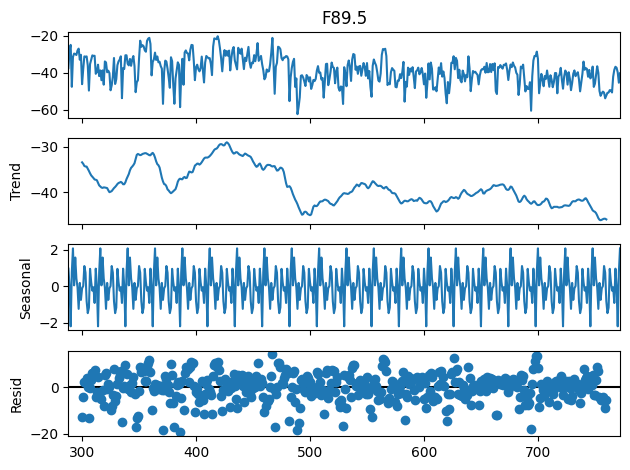

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


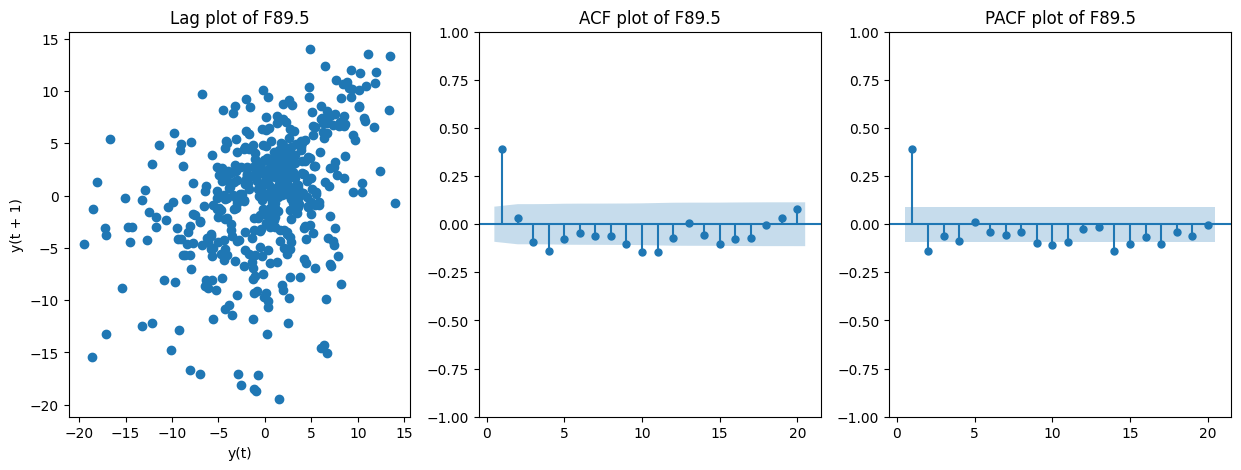

In [73]:
TS = selectTS(trainRawTS, "F89.5", "LT001")
tsDecompResult = additiveDecomp(TS)
autoCorr(tsDecompResult.resid.dropna(), "F89.5")

BUR001 F116 is empty


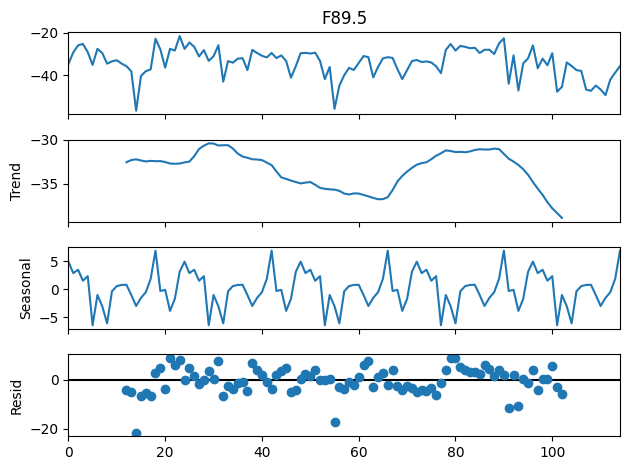

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  BUR001 The frequency is:  F89.5


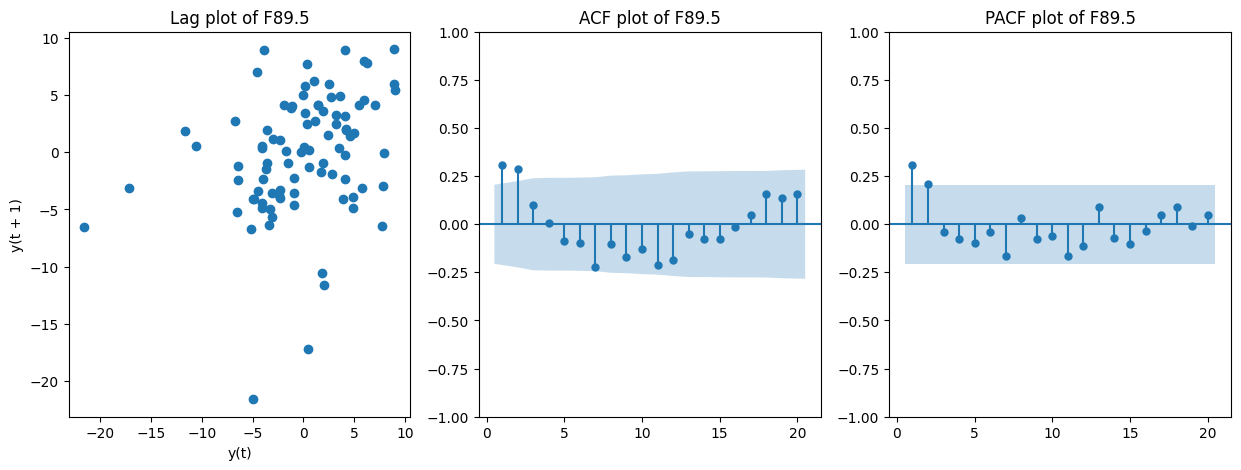

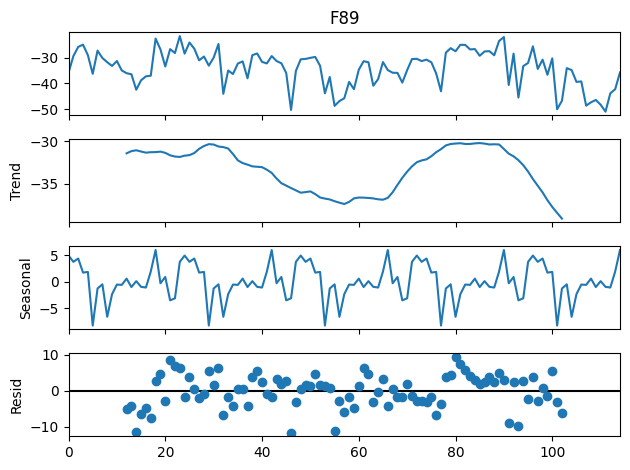

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  BUR001 The frequency is:  F89


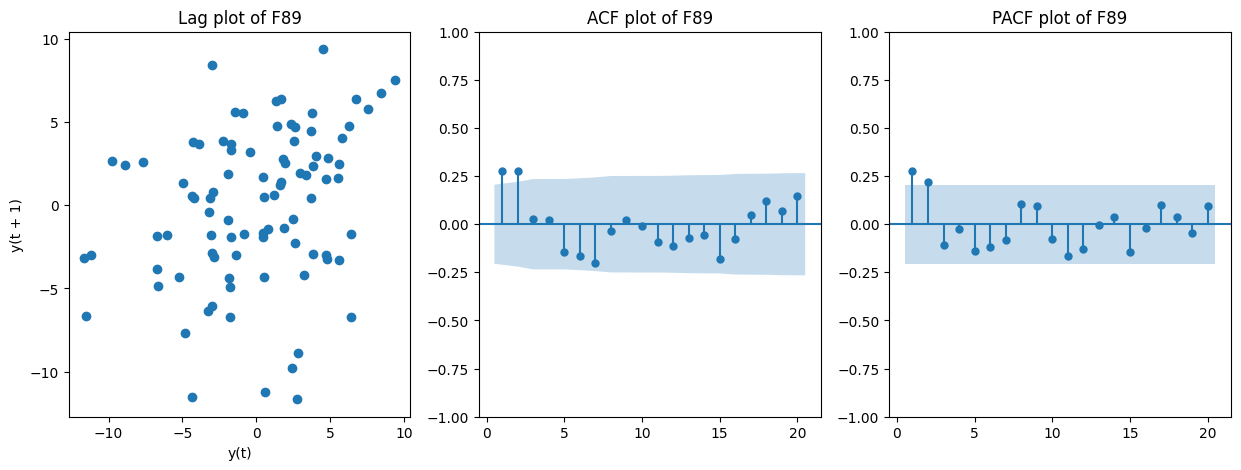

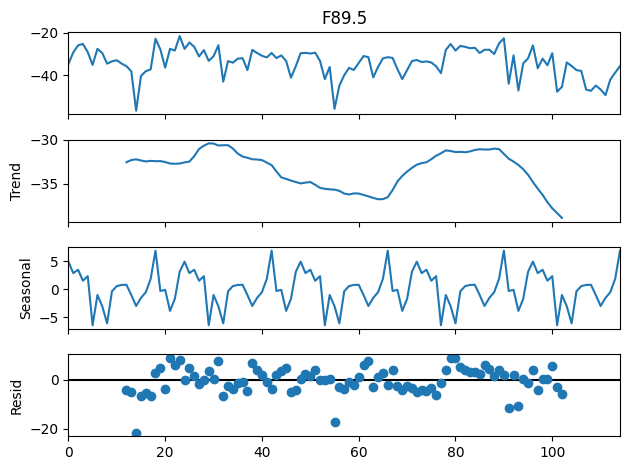

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  BUR001 The frequency is:  F89.5
BUR001 F138.5 is empty
BUR001 F115 is empty
BUR001 F95 is empty
BUR001 F116.5 is empty


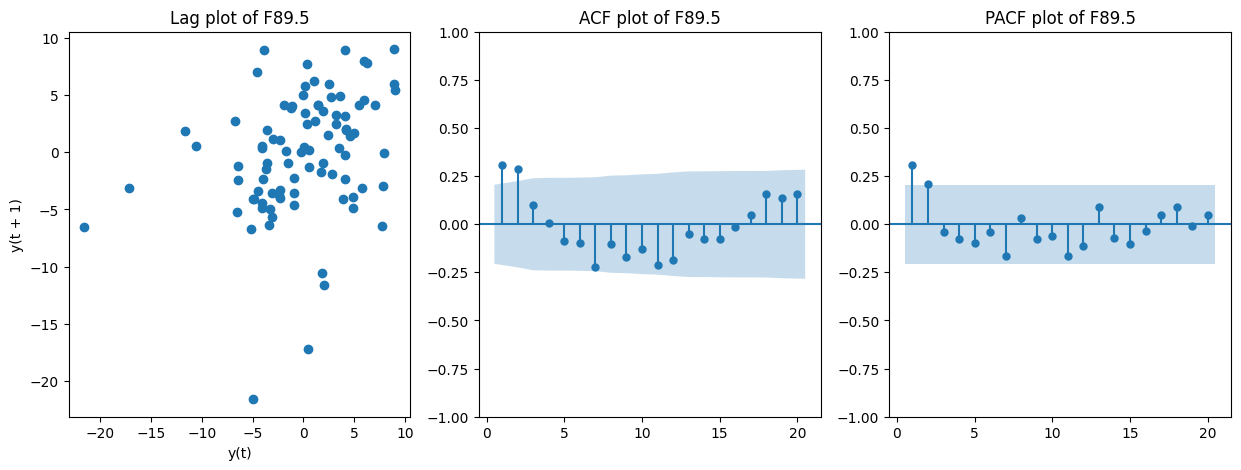

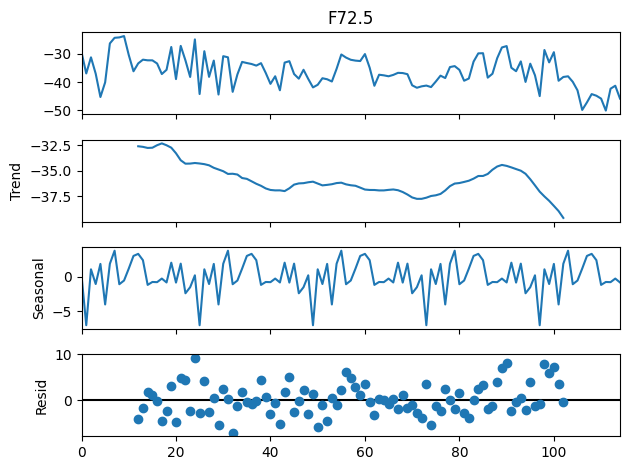

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  BUR001 The frequency is:  F72.5
BUR001 F128.5 is empty
BUR001 F167.5 is empty
BUR001 F140.5 is empty
BUR001 F159 is empty


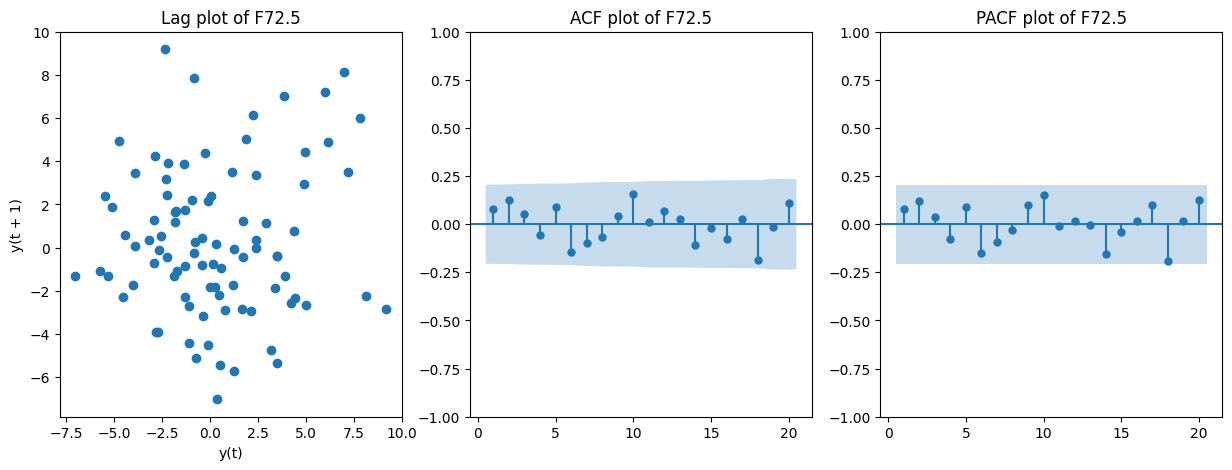

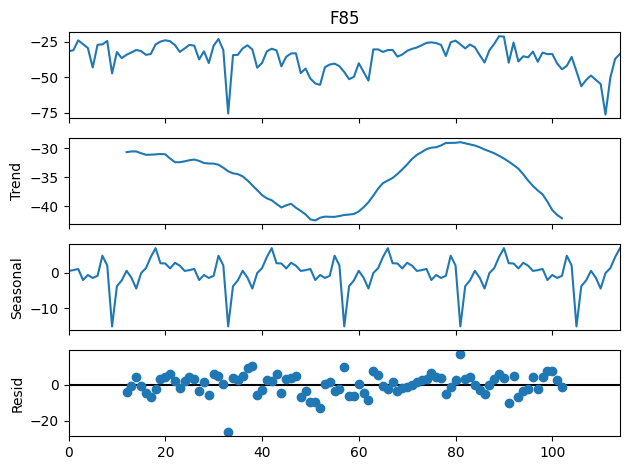

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  BUR001 The frequency is:  F85
BUR001 F137 is empty
BUR001 F150.5 is empty
LT001 F116 is empty


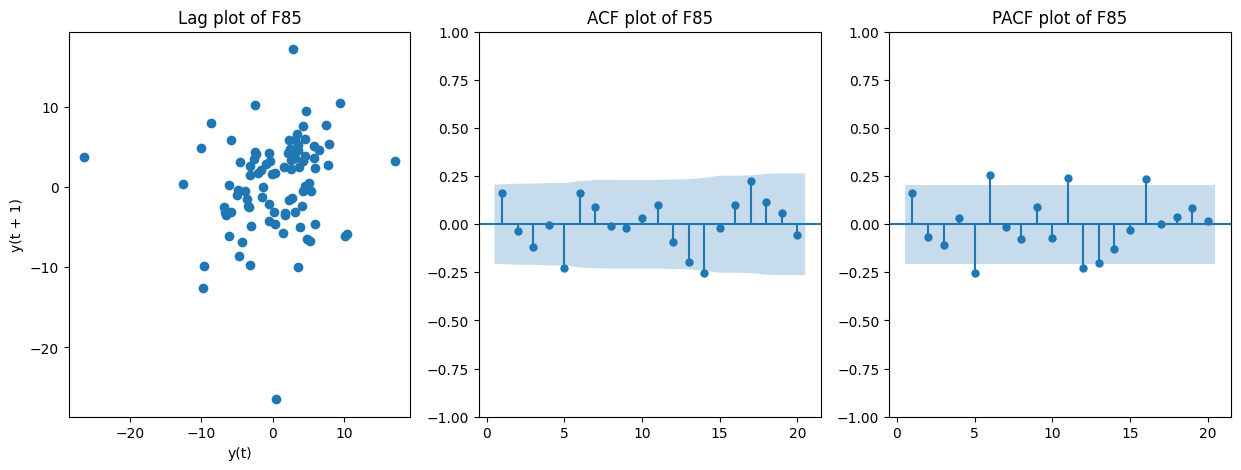

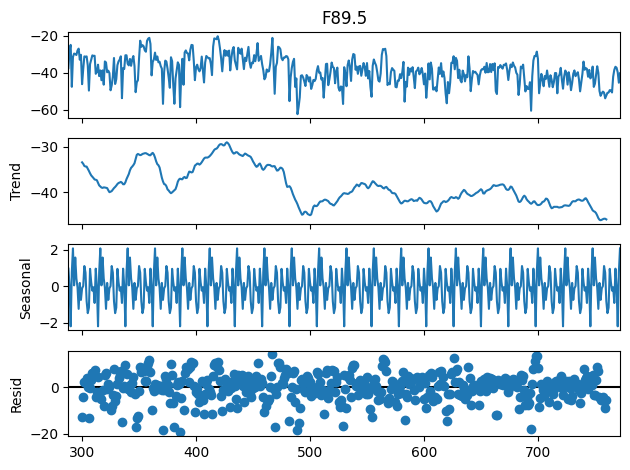

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LT001 The frequency is:  F89.5


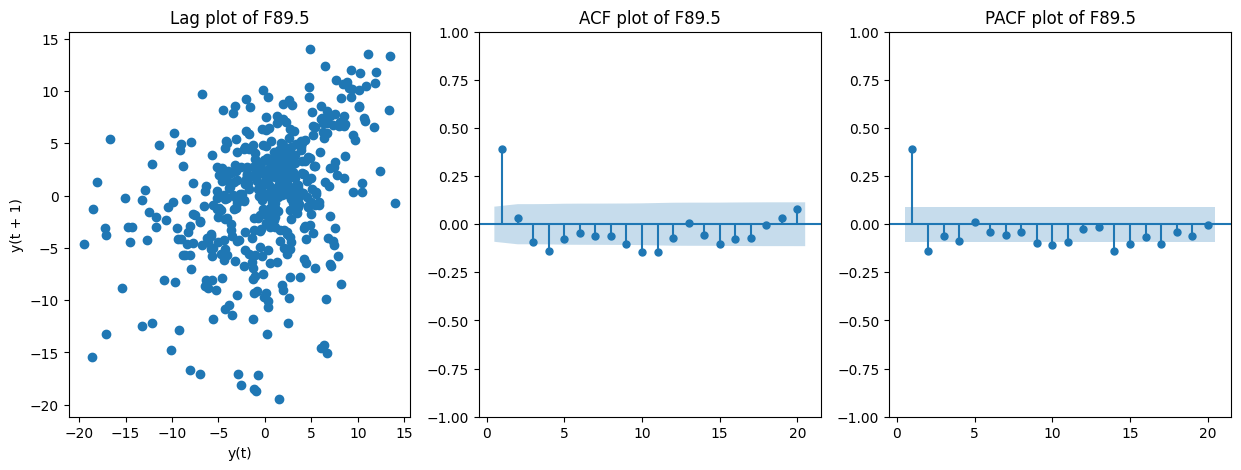

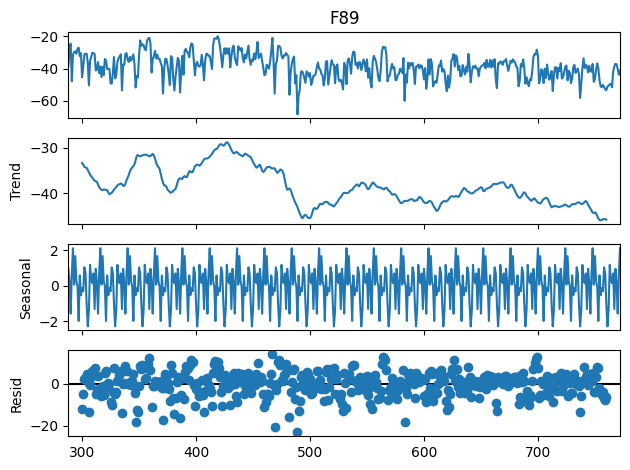

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LT001 The frequency is:  F89


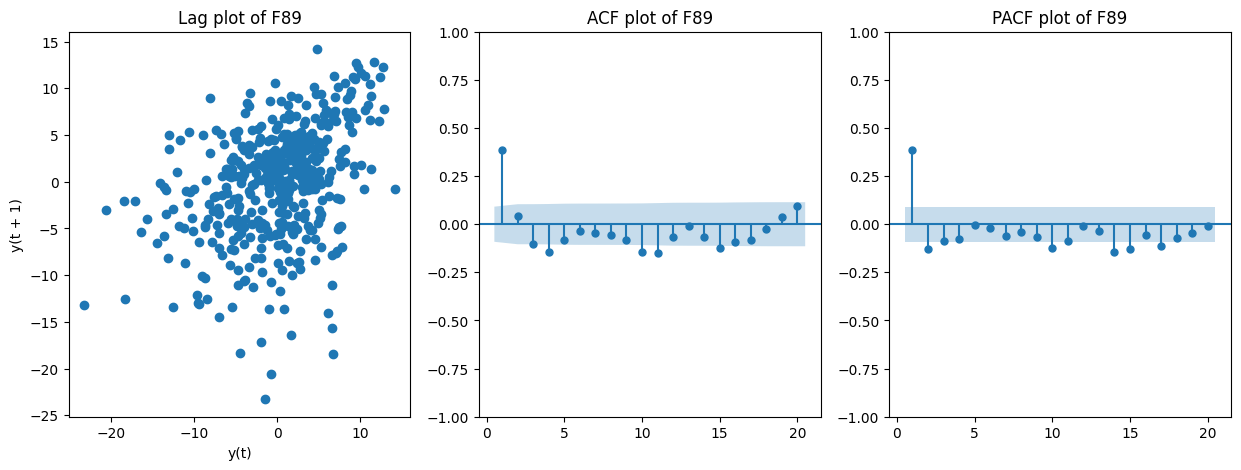

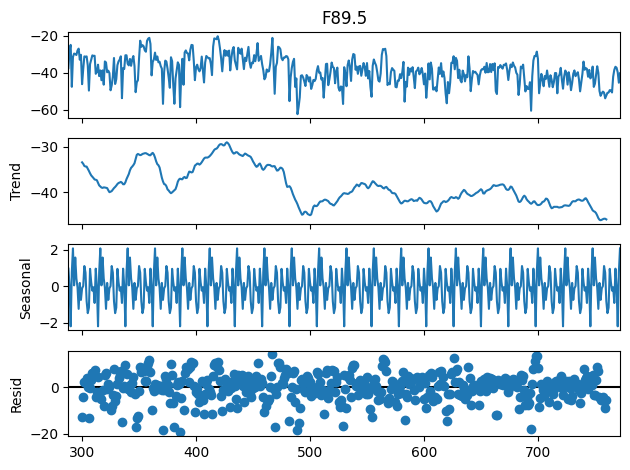

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LT001 The frequency is:  F89.5
LT001 F138.5 is empty
LT001 F115 is empty
LT001 F95 is empty
LT001 F116.5 is empty


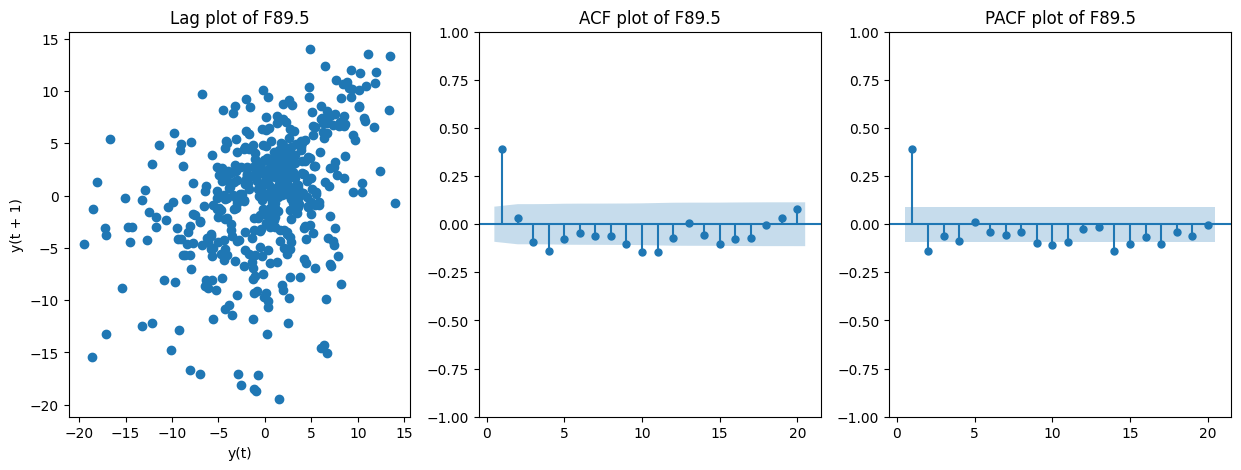

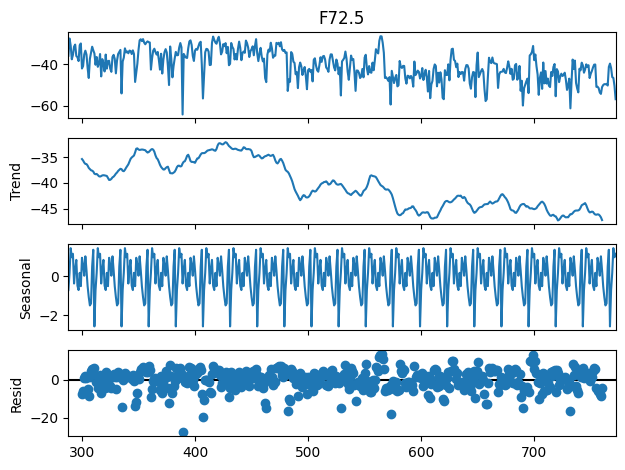

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LT001 The frequency is:  F72.5
LT001 F128.5 is empty
LT001 F167.5 is empty
LT001 F140.5 is empty
LT001 F159 is empty


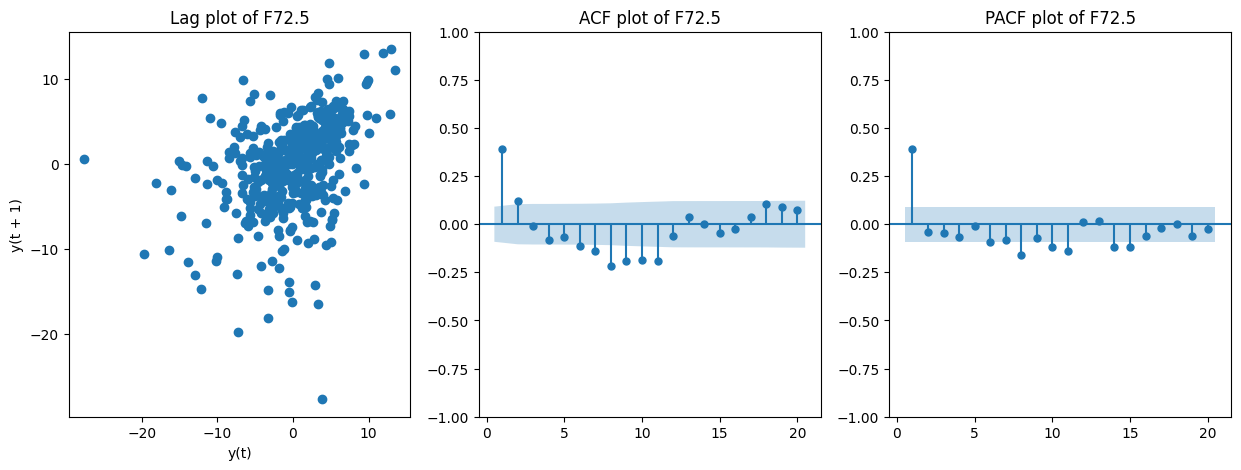

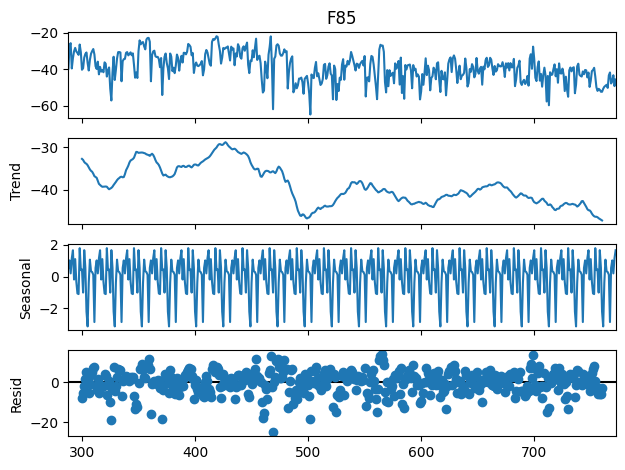

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LT001 The frequency is:  F85
LT001 F137 is empty
LT001 F150.5 is empty
LWF001 F116 is empty


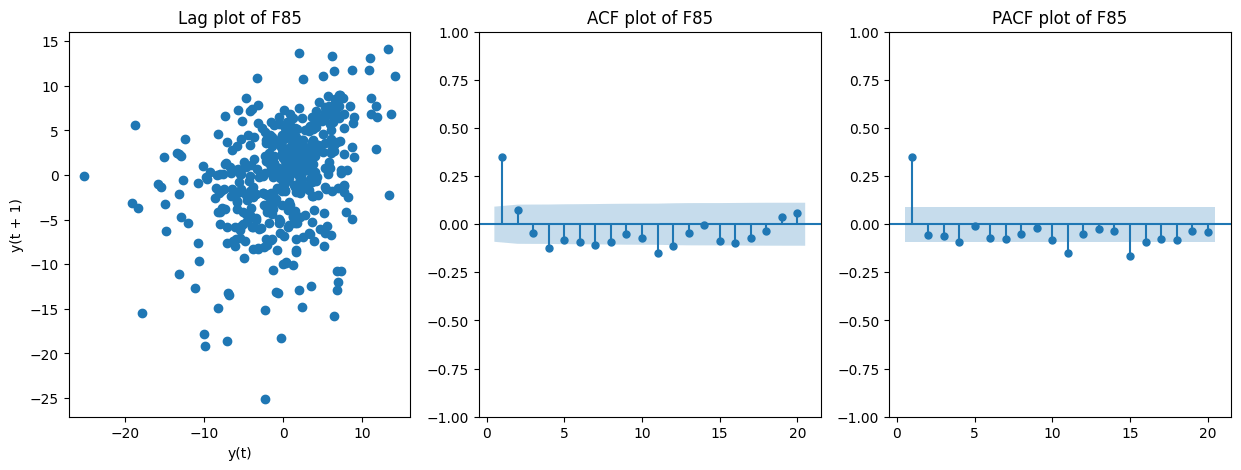

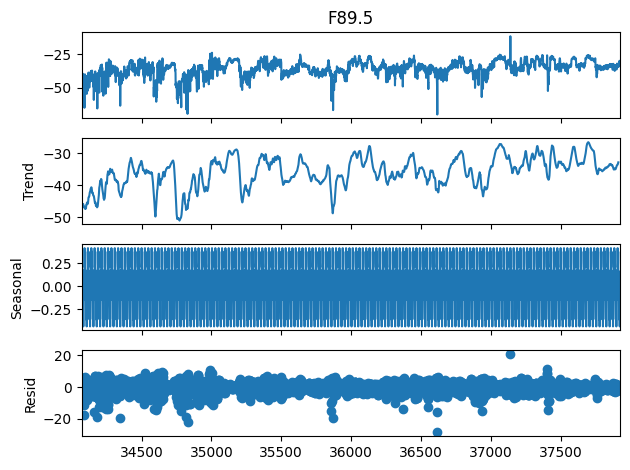

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LWF001 The frequency is:  F89.5


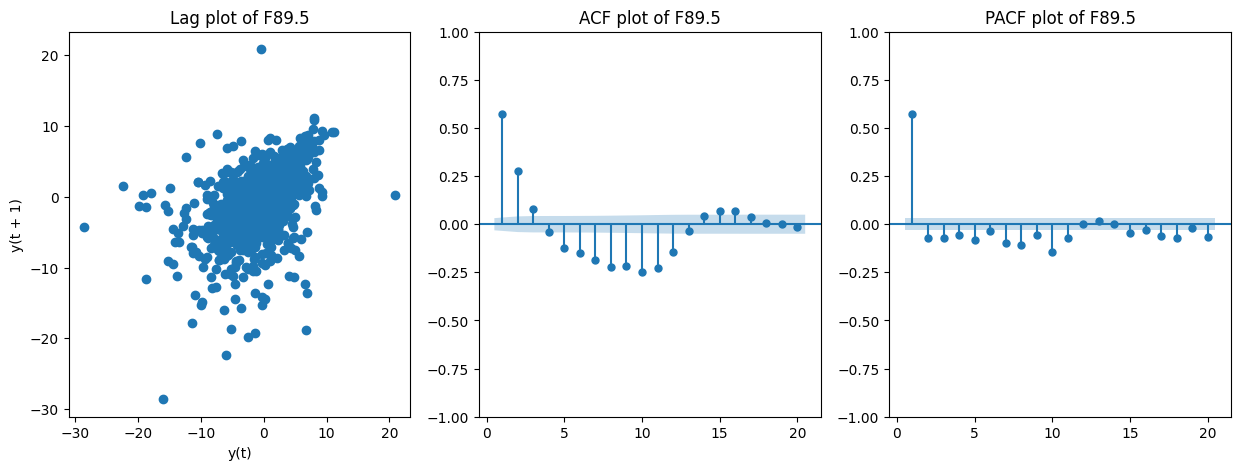

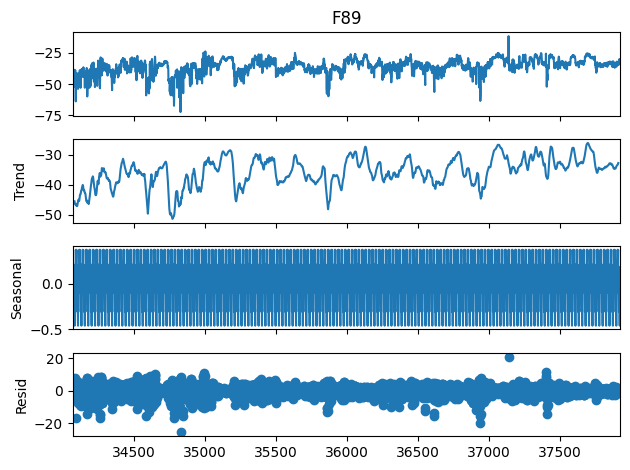

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LWF001 The frequency is:  F89


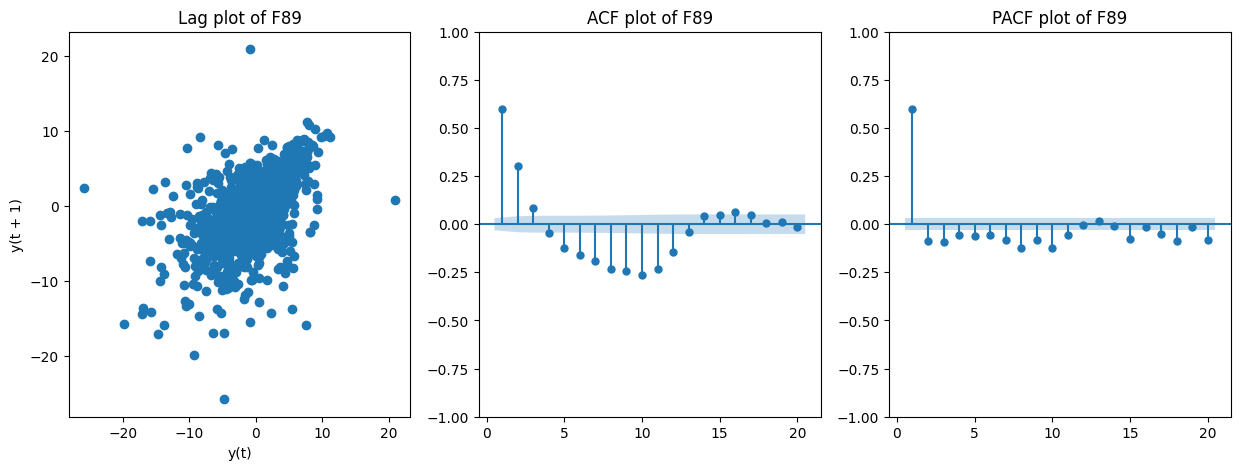

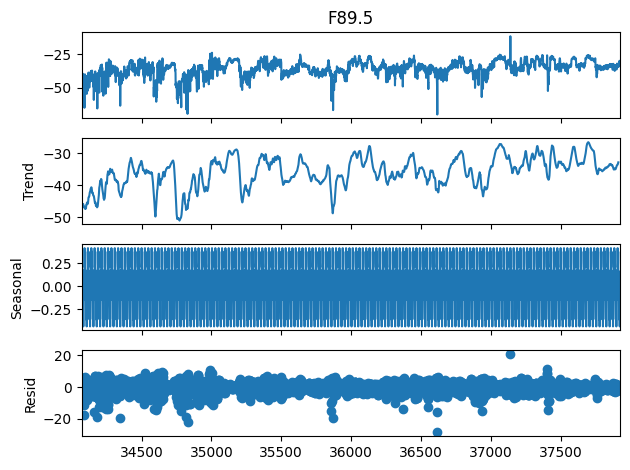

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LWF001 The frequency is:  F89.5
LWF001 F138.5 is empty
LWF001 F115 is empty
LWF001 F95 is empty
LWF001 F116.5 is empty


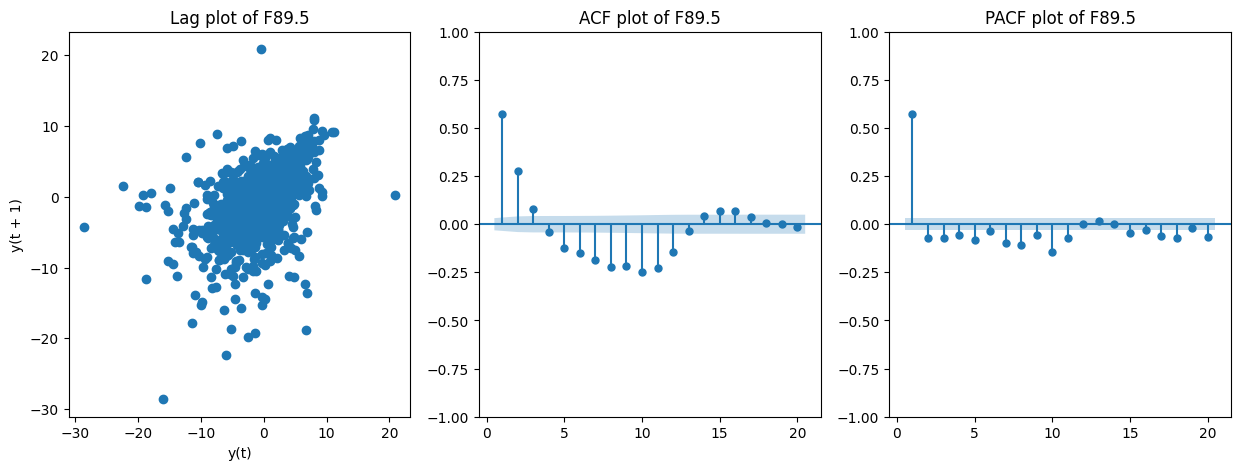

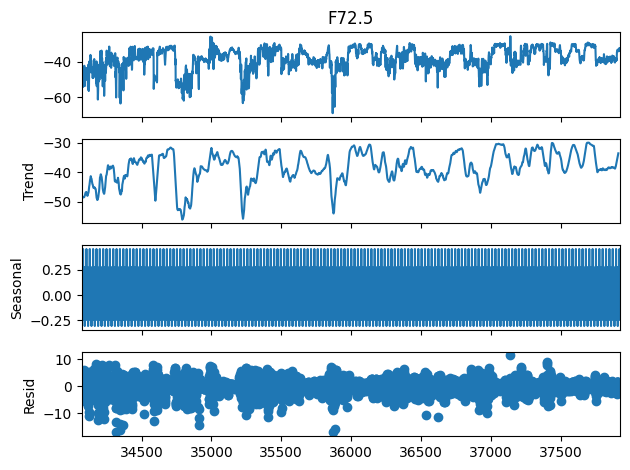

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LWF001 The frequency is:  F72.5
LWF001 F128.5 is empty
LWF001 F167.5 is empty
LWF001 F140.5 is empty
LWF001 F159 is empty


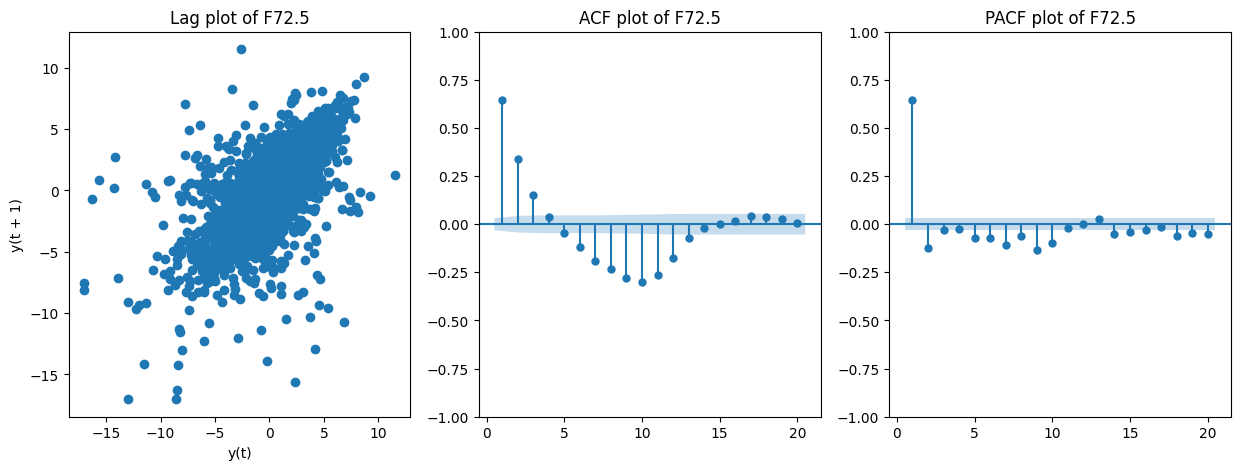

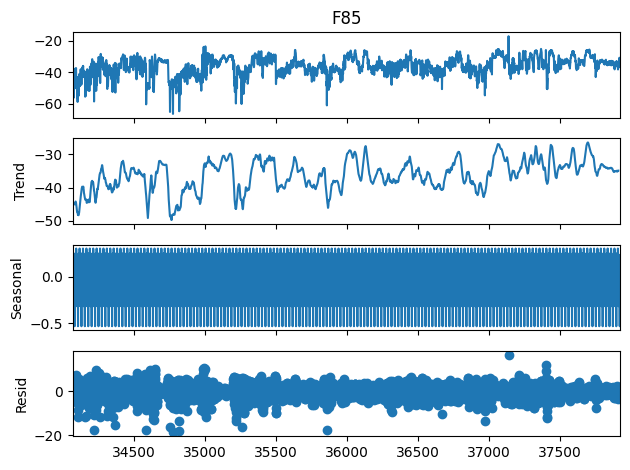

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  LWF001 The frequency is:  F85
LWF001 F137 is empty
LWF001 F150.5 is empty


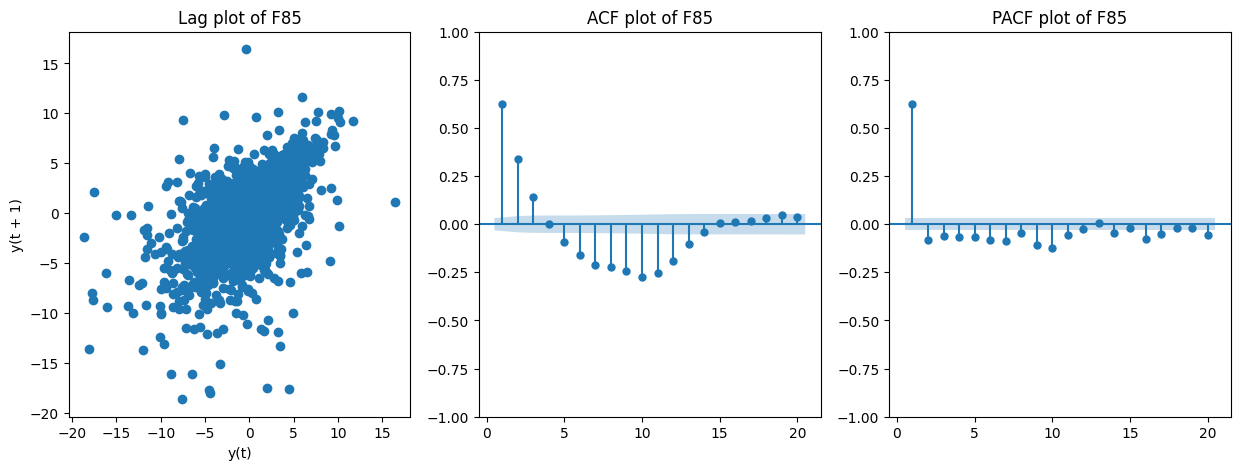

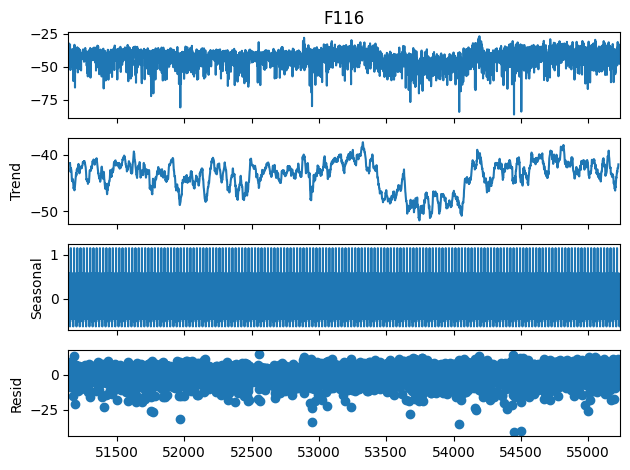

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F116


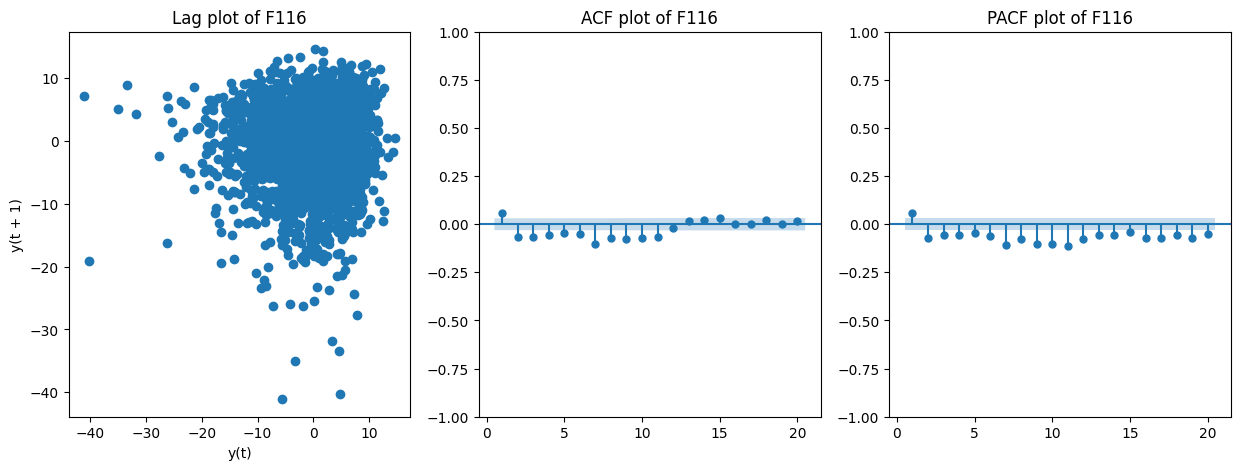

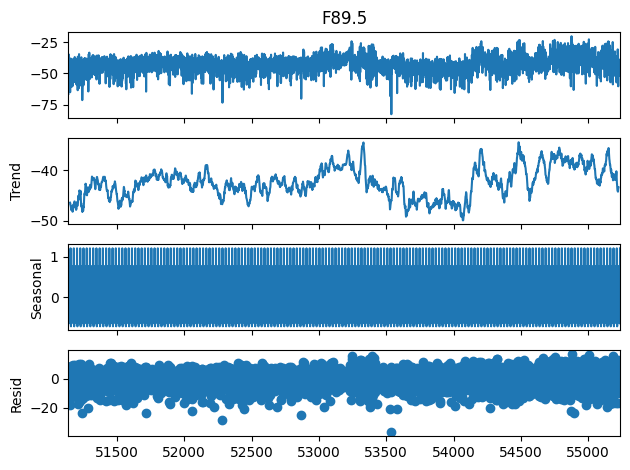

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F89.5


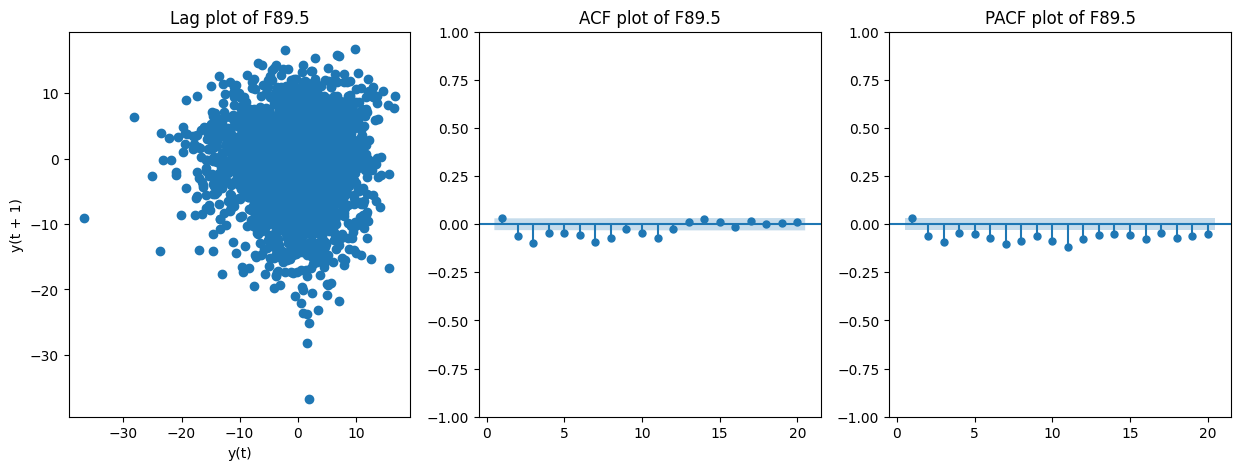

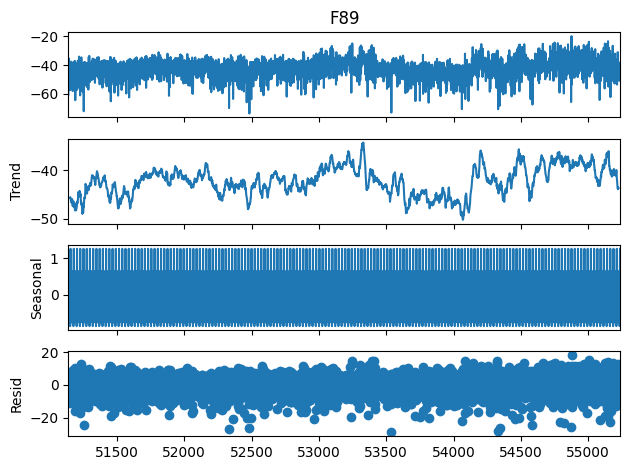

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F89


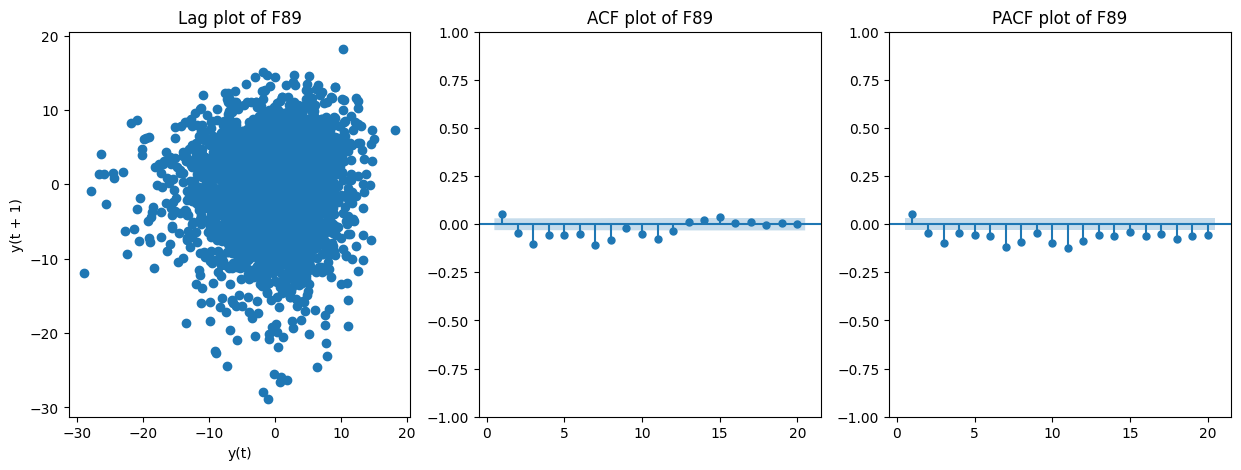

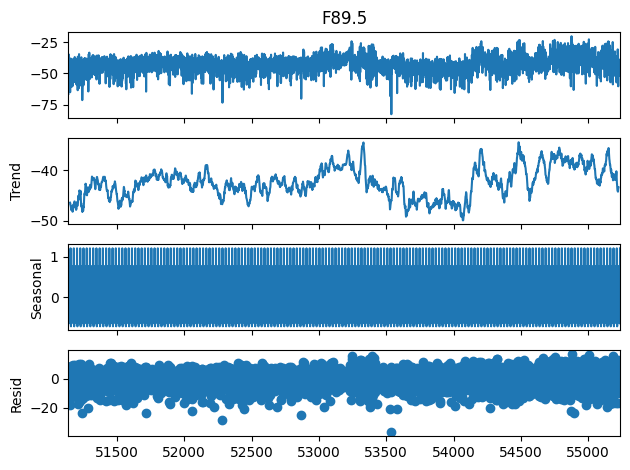

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F89.5


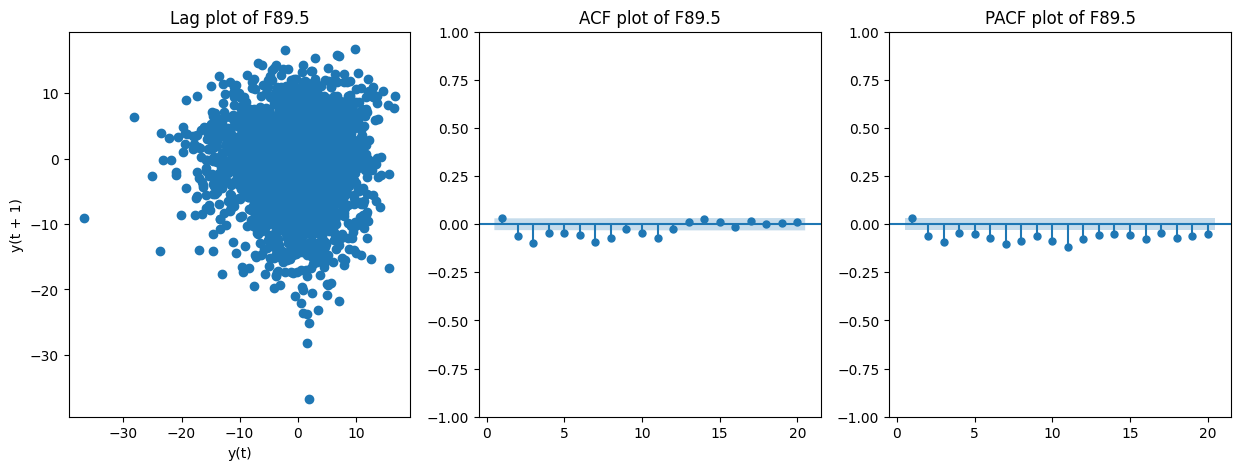

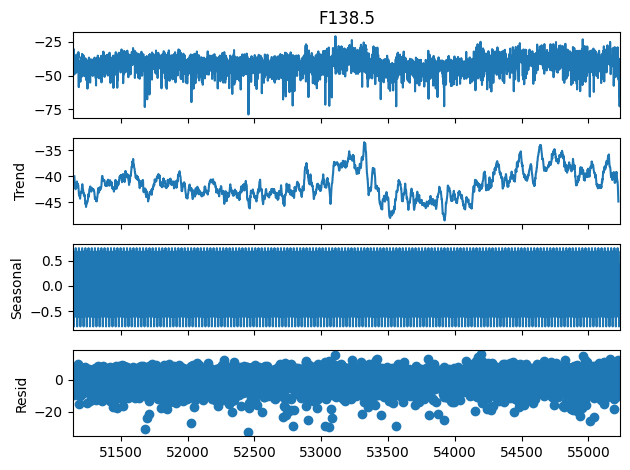

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F138.5


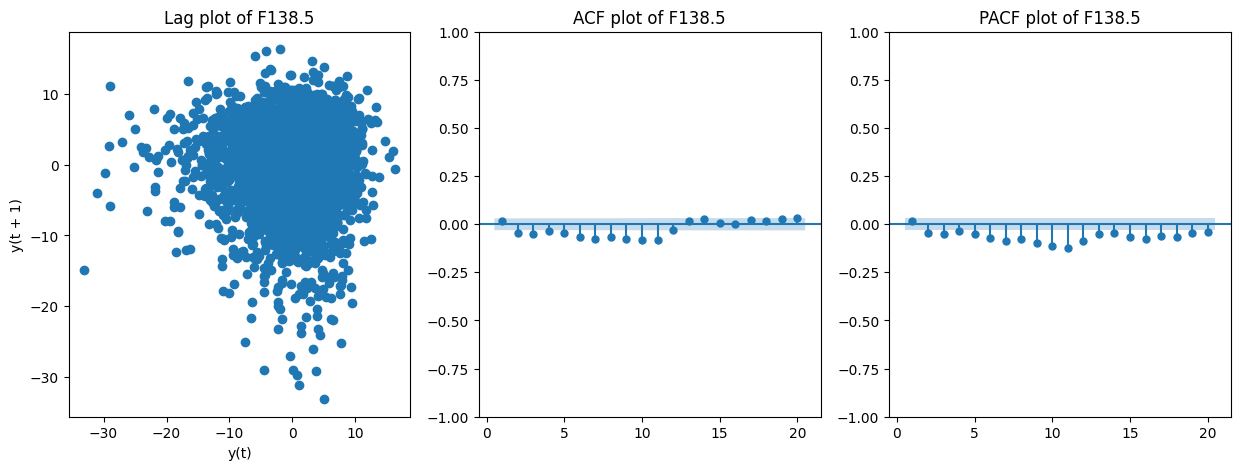

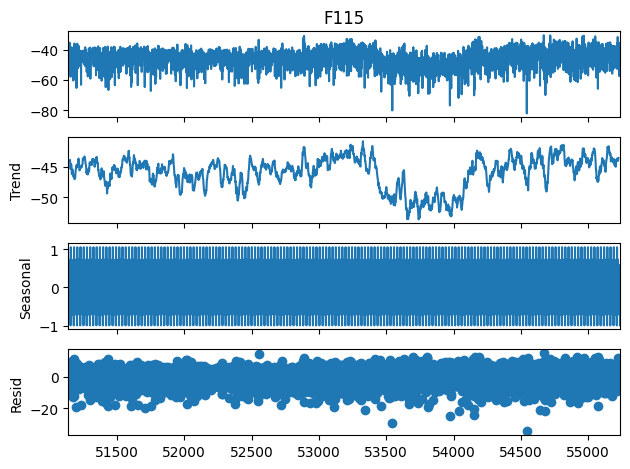

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F115


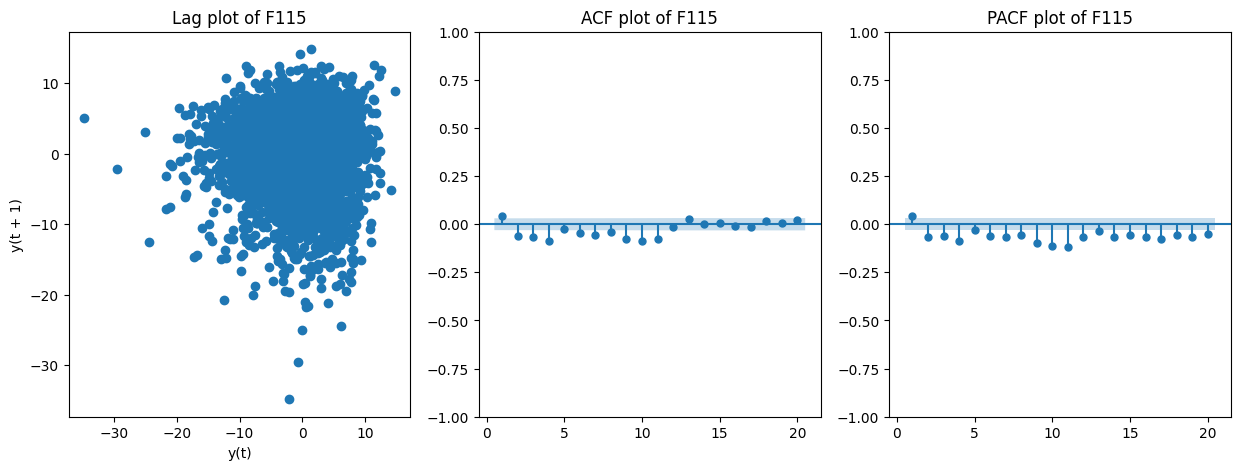

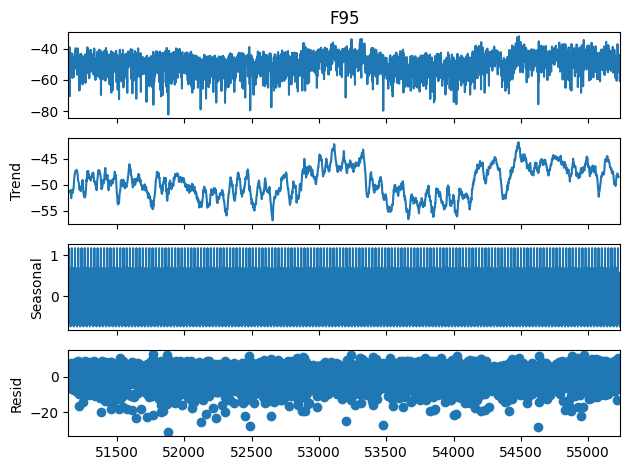

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F95


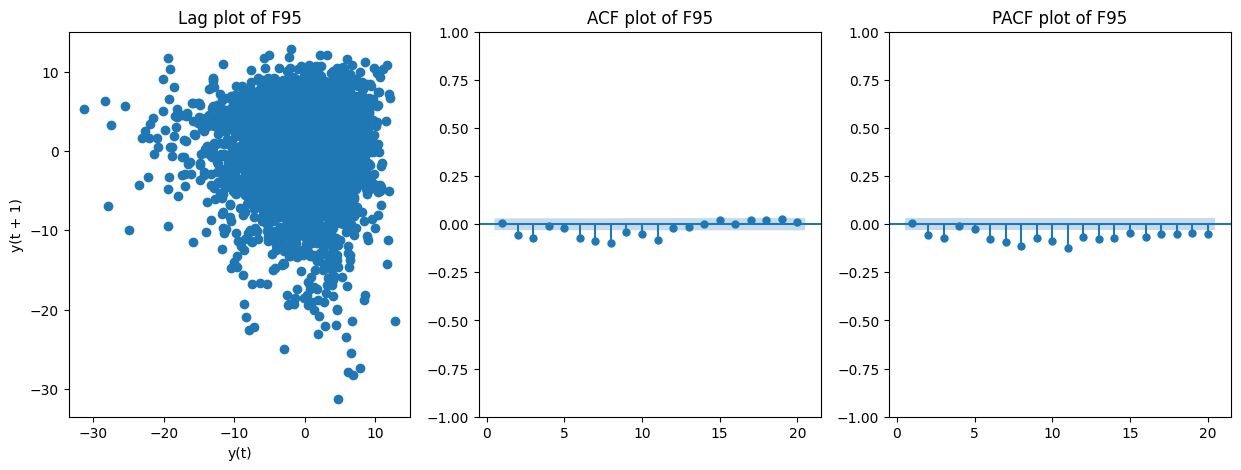

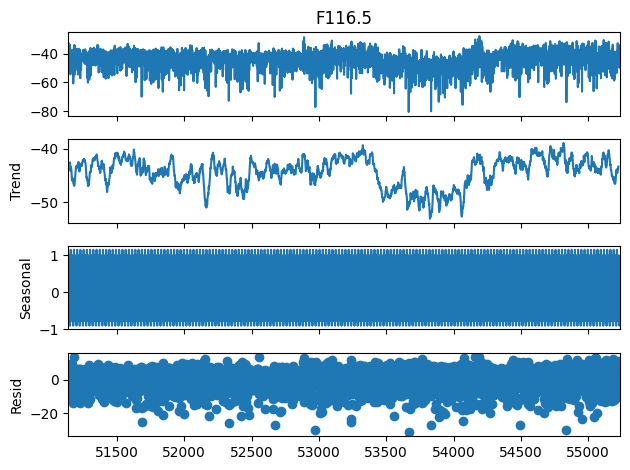

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F116.5


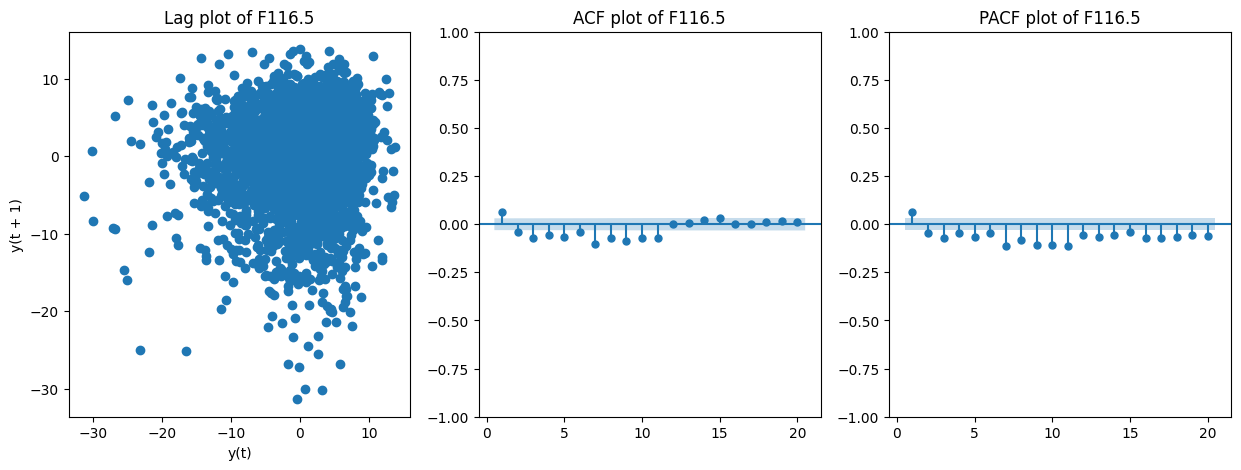

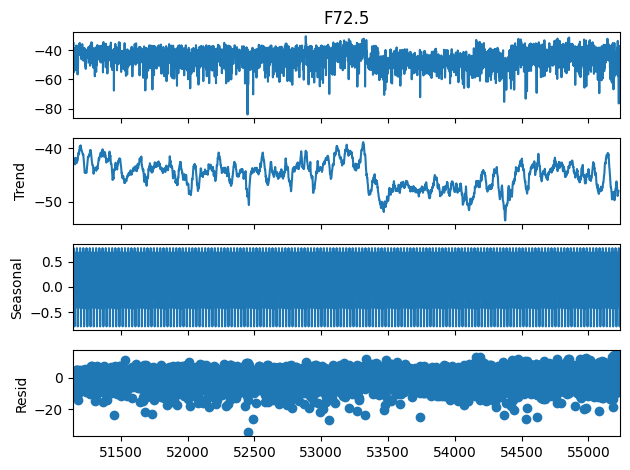

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F72.5


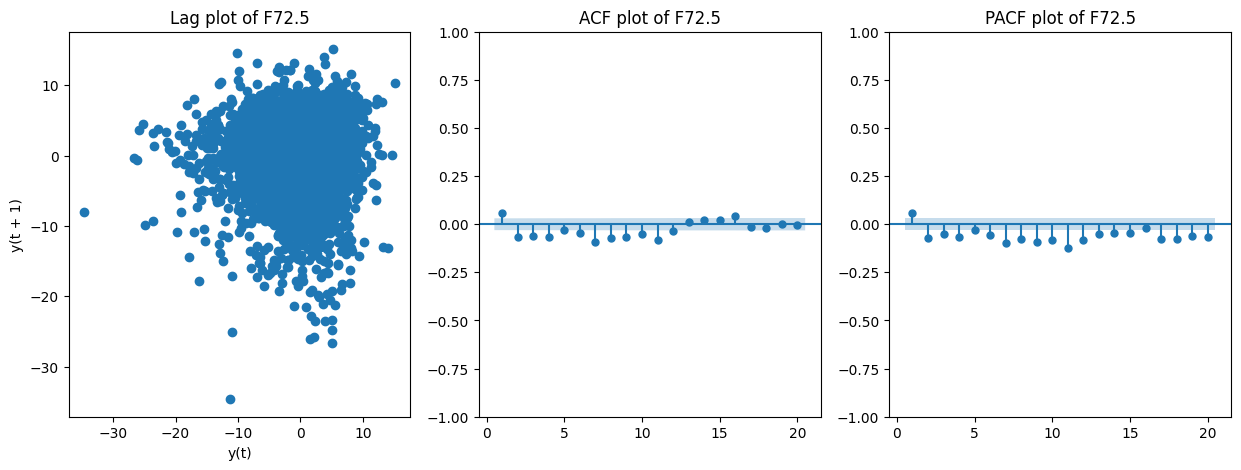

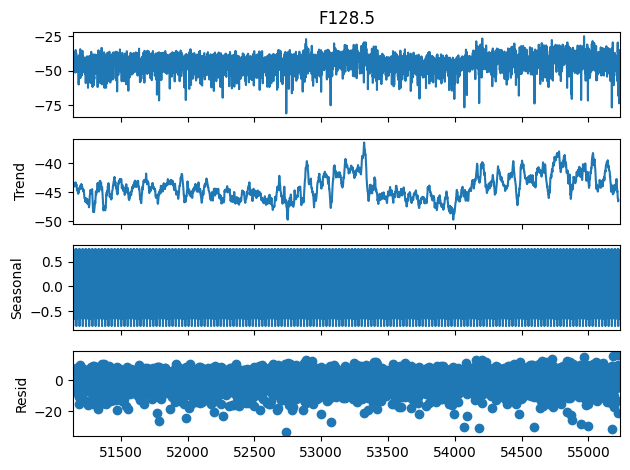

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F128.5


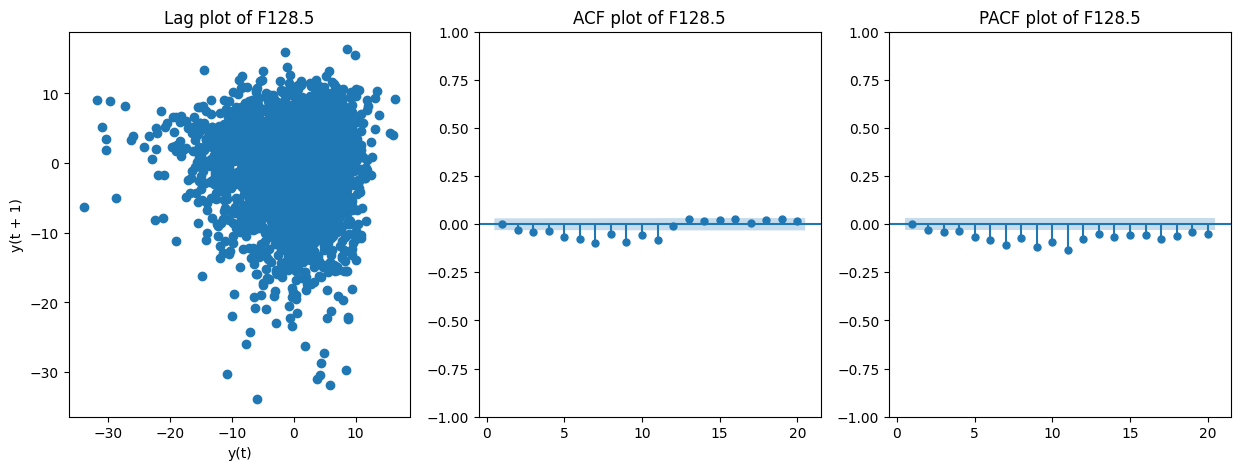

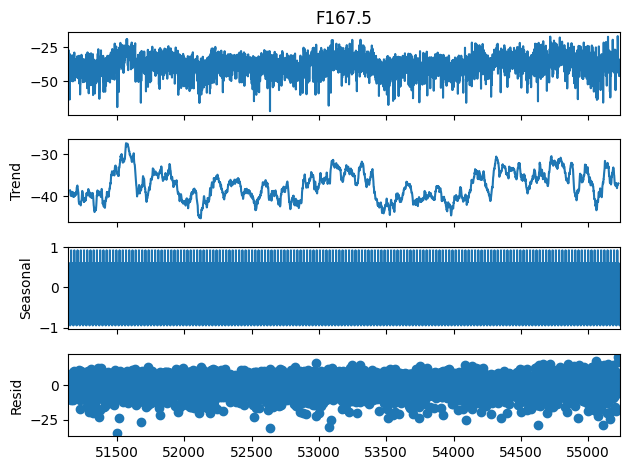

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F167.5


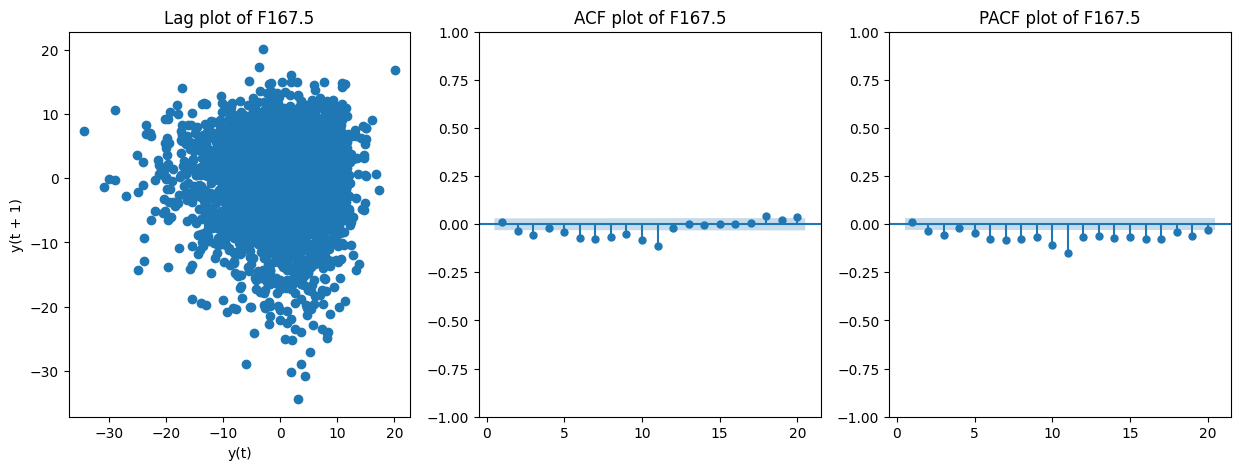

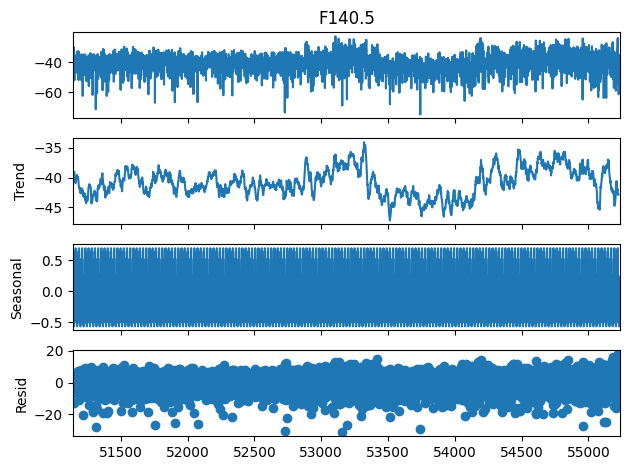

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F140.5


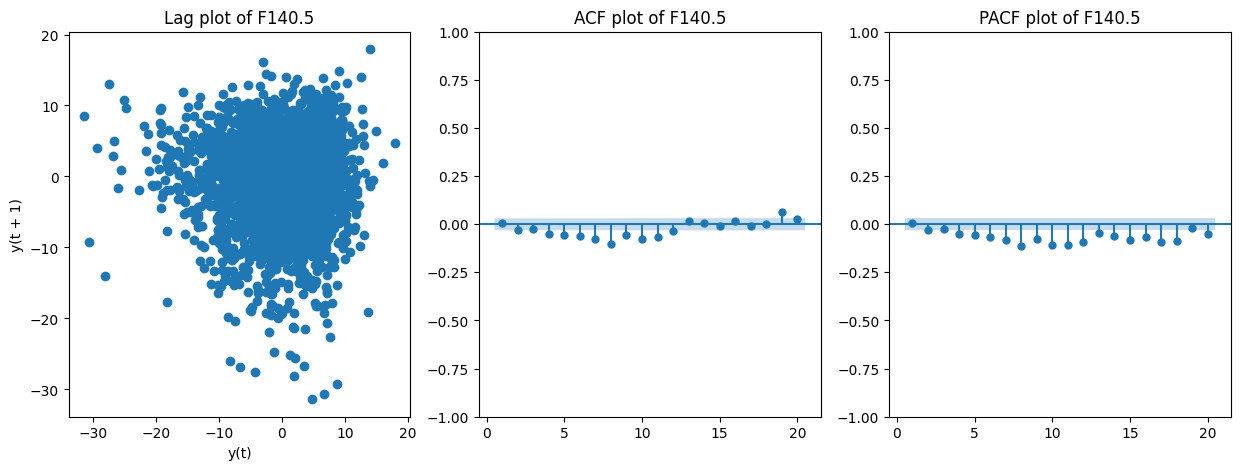

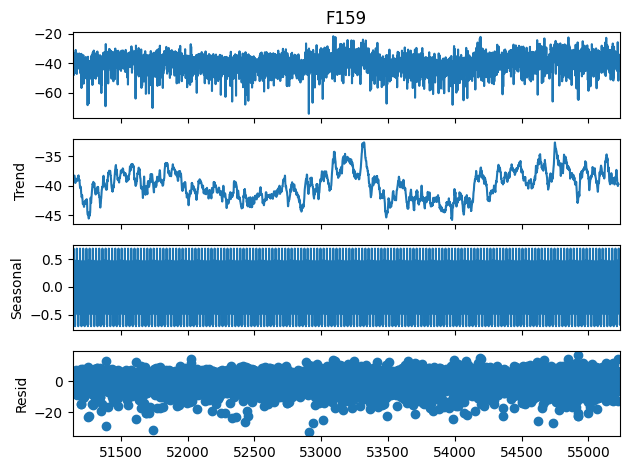

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F159


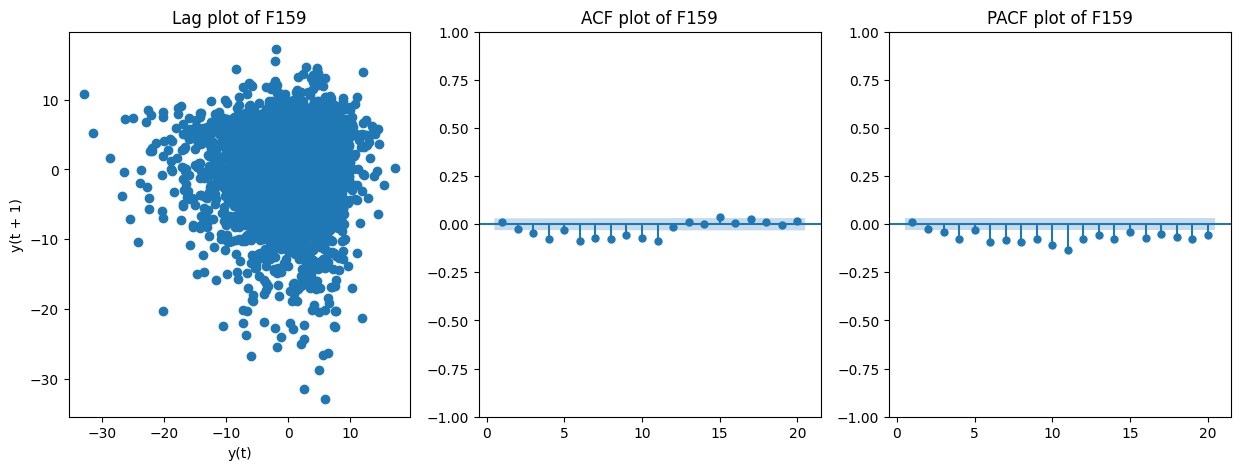

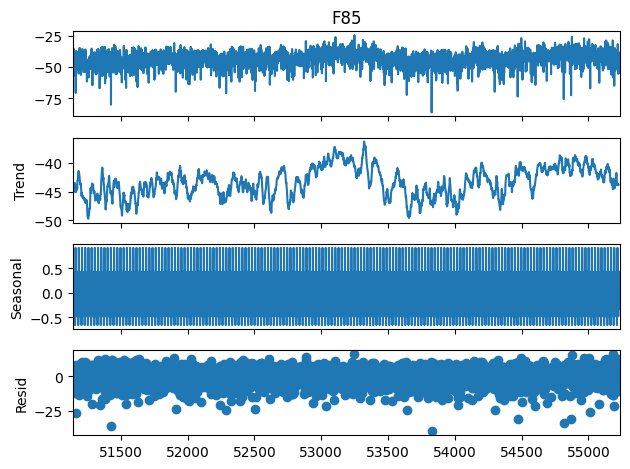

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F85


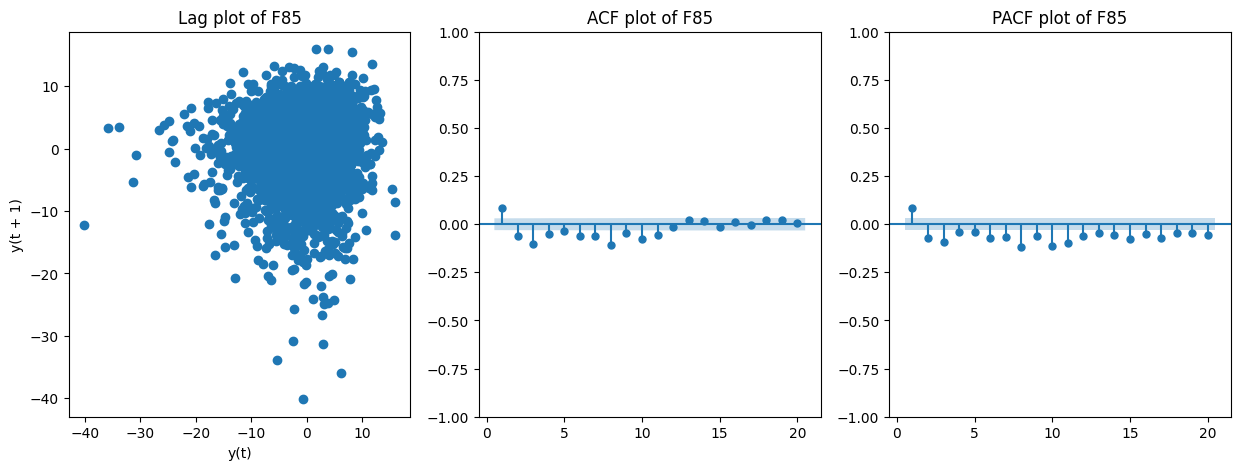

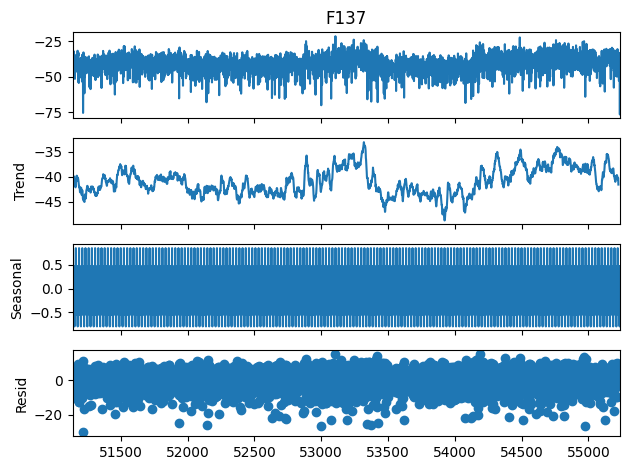

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F137


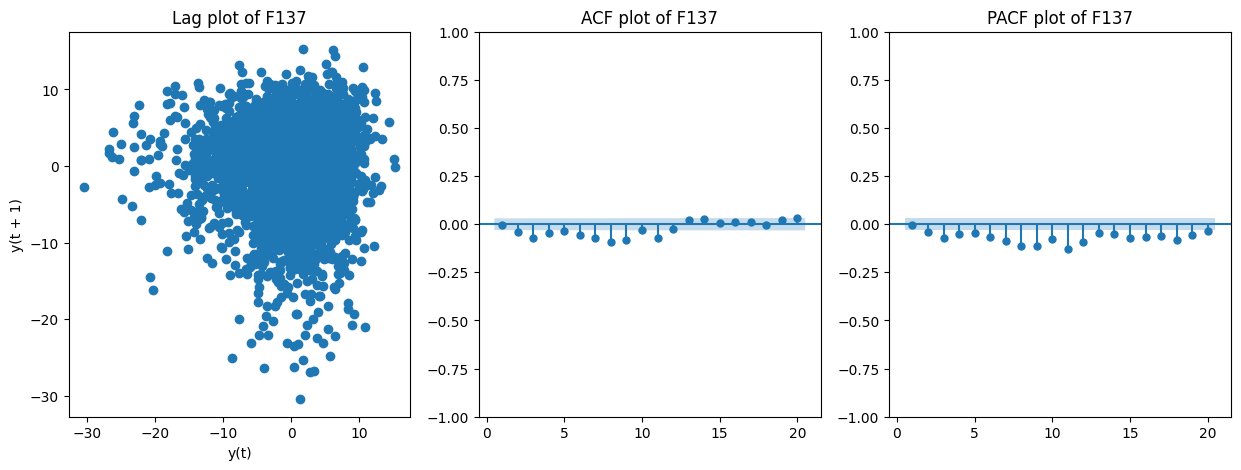

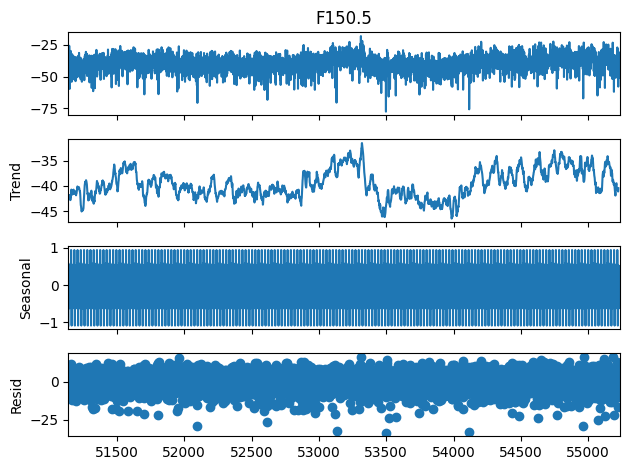

C:\Users\86139\AppData\Local\Temp\ipykernel_17160\1091381670.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


The fish number is:  SMB001 The frequency is:  F150.5


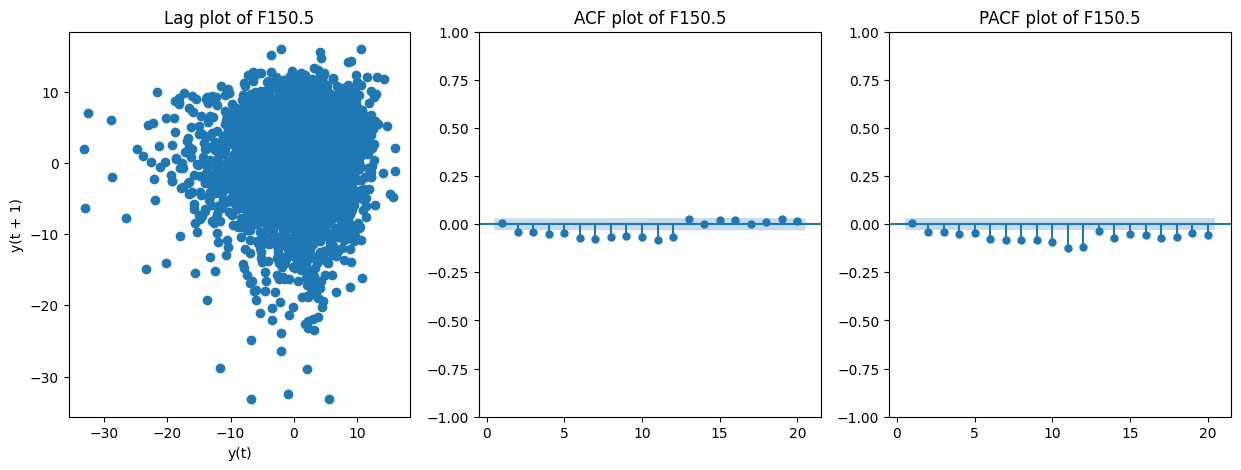

In [74]:
freqList = ["F116", "F89.5", "F89", "F89.5", "F138.5", "F115",
            "F95", "F116.5", "F72.5", "F128.5", "F167.5", "F140.5",
            "F159", "F85", "F137", "F150.5"]
freList =sorted(freqList)

fishList = ["BUR001", "LT001", "LWF001", "SMB001"]

for fish in fishList:
    for freq in freqList:
        temporalEDA(trainRawTS, freq, fish)

**Observations**:

1. Autocorrelation is positive
2. ACF decays very slow, but PCAF decays after lag 2, suggesting an AR(2) model might be appropriate to model the time series.
3. Although PCAF decays quickly to 0, it can still bounce back to above the confidence band after lag 2. Such a bounce back might occur in the third lag.
4. PCAF fluctuates around 0

# 2. Additive Trend Decomposition

**Observations**
1. Original time series exhibits periodical spikes
2. Trend is non-stationary with periodical fluctuations
3. Residuals have occasional extreme values as low as -20

**Observations**
1. Non-stationary trend
2. Seasonality patterns differ by frequncies
3. Occassional extreme residuals

# 2. Additive Decomposition with Differencing

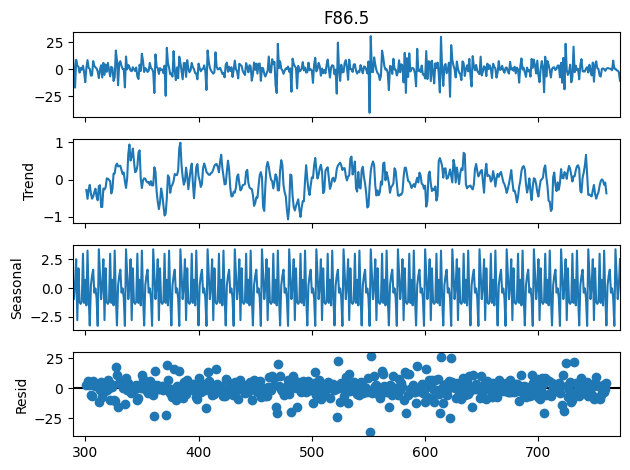

In [60]:
def additiveDiffDecomp(data, freq, fishNum, period=24, diff=1):
    ''' 
    Plots the additive decomposition of the time series data
    @ data: the data frame
    @ freq: the frequency of the data
    @ fishNum: the fish number
    return: None
    '''
    # select the column
    TS = data.loc[data['fishNum'] == fishNum, freq]
    TS = pd.Series(TS).dropna()


    if TS.empty:
        print('No data for fish number ', fishNum, "at frequency ", freq)
        return None
    
    TS_diff = TS.diff(diff).dropna()

    # decompose the time series
    result = seasonal_decompose(TS_diff, model='additive', period=24)
    result.plot()
    plt.show()
    return result
    
LT001F86_decomp = additiveDiffDecomp(trainRawTS, "F86.5", "LT001", period=10)

No data for fish number  LT001 at frequency  F116


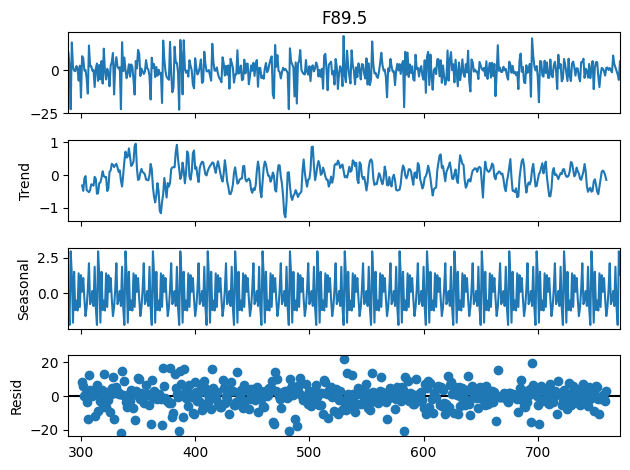

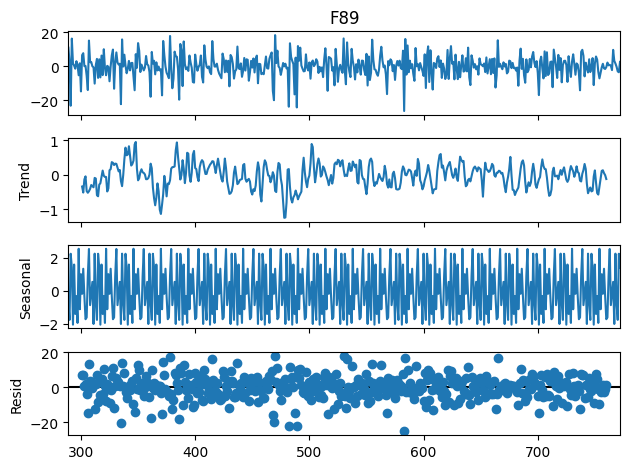

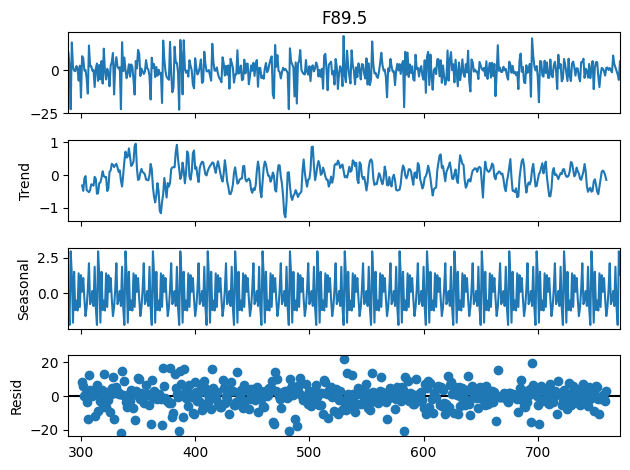

No data for fish number  LT001 at frequency  F138.5
No data for fish number  LT001 at frequency  F115
No data for fish number  LT001 at frequency  F95
No data for fish number  LT001 at frequency  F116.5


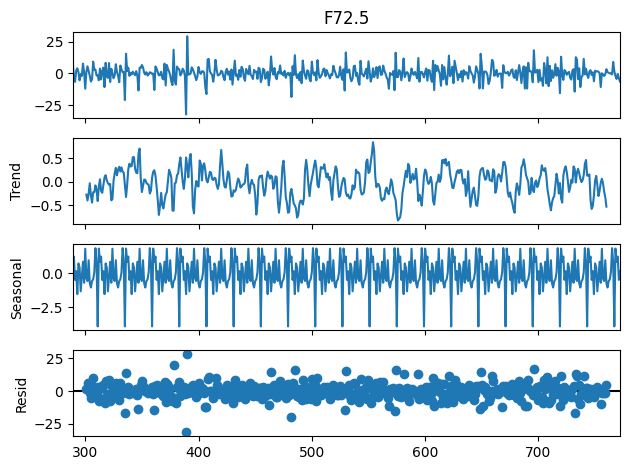

No data for fish number  LT001 at frequency  F128.5
No data for fish number  LT001 at frequency  F167.5
No data for fish number  LT001 at frequency  F140.5
No data for fish number  LT001 at frequency  F159


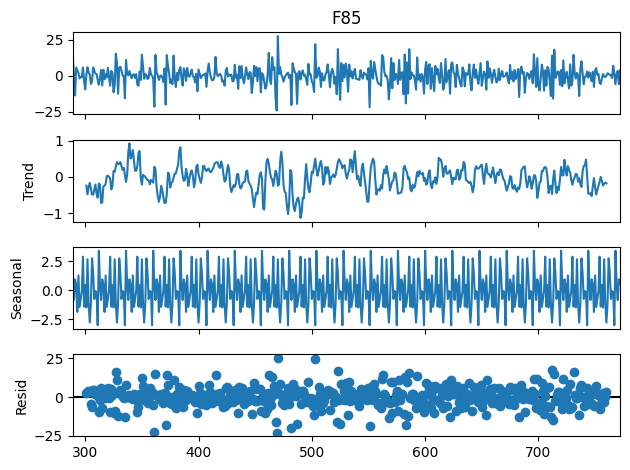

No data for fish number  LT001 at frequency  F137
No data for fish number  LT001 at frequency  F150.5


In [59]:
for freq in freqList:
    # for fish in fishList:
    additiveDiffDecomp(trainRawTS, freq, "LT001", 24)

**Observations**
1. Original time series centered at 0 with apparent volatility clusters
2. Non-stationary trend, however, the actual trend of the differenced series should be zero as no mean shift is seen.
3. Large volatility points are also reflected in corresponding areas in the residual plots

# 4. Multiplicative model

In [68]:
def multiDiffDecomp(data, freq, fishNum, period=24, diff=1):
    ''' 
    Plots the multiplicative decomposition of the time series data after differencing with a lag 1
    @ data: the data frame
    @ freq: the frequency of the data
    @ fishNum: the fish number
    return: None
    '''
    # select the column
    TS = data.loc[data['fishNum'] == fishNum, freq]
    TS = pd.Series(TS).dropna()


    if TS.empty:
        print('No data for fish number ', fishNum, "at frequency ", freq)
        return None
    
    # TS_diff = TS.diff(diff).dropna()

    # decompose the time series
    result = seasonal_decompose(TS, model='multiplicative', period=24)
    result.plot()
    plt.show()
    return result
    
try :
    LT001F86_decomp = multiDiffDecomp(trainRawTS, "F86.5", "LT001", period=24)
except ValueError:
    print("Negative input value for multiplicative decomposition is inapplicable")

Negative input value for multiplicative decomposition is inapplicable


# 2. PCA for Dimensional Reduction

In [ ]:
trainMeanTS = pd.read_csv("C:/Users/86139/Desktop/FishTetherExperiment/ProcessedData/edaFreqMean.csv", index_col=0)
trainMeanTS.head()

In [ ]:
freqCols = trainMeanTS.columns.str.startswith('F')
globalMean = trainMeanTS.loc[:, freqCols].mean()
trainMeanTS.loc[:, freqCols] = trainMeanTS.loc[:, freqCols].fillna(globalMean)

In [ ]:
print(trainMeanTS.isnull().sum())

In [31]:
X = np.array(trainMeanTS.loc[:,freqCols])
X = StandardScaler().fit_transform(X)

pattern = r'([A-Za-z]+)(\d+)'
Y = trainMeanTS.fishNum.str.extract(pattern)

In [ ]:
def customPCA(X, n_components=10):
    """
    Perform PCA on all individuals in a given species
    :param df: a DataFrame with a column being the fish number and the rest being frequencies
    :param groupVar: a string, the column name of the group variable
    :param freqVar: a list of strings, the column names of the frequencies
    :return: dictionary containing a DataFrame with the first 2 principle components, 
    a list of the explained variance ratio, and the frequency names, and the first 3 principle components
    """
    print("Stenadardizer set up")
    X = StandardScaler().fit_transform(X)
    print("PCA set up")
    pca = PCA(n_components=n_components)
    pca.fit(X)

    V3 = pca.components_[:3]  # the first three principle vectors
    propExplained = pca.explained_variance_ratio_
    
    # 3D Projection
    Z3 = pd.DataFrame(X @ V3, columns=['PC1', 'PC2', 'PC3'])
    # Z3 = pd.DataFrame(Z3, columns=['PC1', 'PC2', 'PC3']) # The first three score vectors
    # Z3.rename(columns={0: "PC1", 1: "PC2", 2: "PC3"}, inplace=True)

    return {"PC": V3.T, "Scree": propExplained, "Projection": Z3}
    

PCA_res = customPCA(X, 10)

C:\Users\86139\AppData\Local\Temp\ipykernel_34092\1383899823.py:20: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



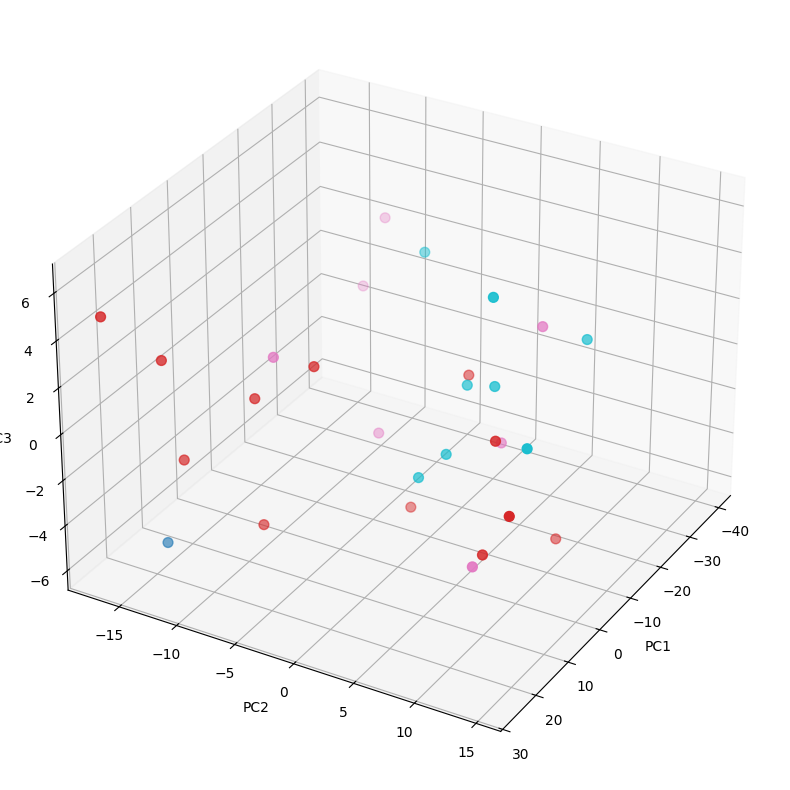

In [68]:
V3 = PCA_res["PC"]
Z3 = pd.DataFrame(X @ V3, columns=['PC1', 'PC2', 'PC3'])

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z3.PC1, Z3.PC2, Z3.PC3, c=Y[0].astype('category').cat.codes, cmap='tab10', s=50)
ax.view_init(elev=30., azim=30)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.mouse_init()  # Enable rotation
# Plot the first 3 principle components
# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(Z3.PC1, Z3.PC2, Z3.PC3, c=Y[0].astype('category').cat.codes, cmap='tab10', s=50)
# ax.view_init(elev=30., azim=30)
# ax.set_xlabel('PC1')
# ax.set_ylabel('PC2')
# ax.set_zlabel('PC3')
fig.show()

In [60]:
fig = px.scatter_3d(Z3, x='PC1', y='PC2', z='PC3', color=Y[0].astype('category').cat.codes, labels={'color': 'Fish Category'})
fig.update_layout(scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'))
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed